In [ ]:
# --- Создание структуры документации (исправленная версия) ---

import json
import re
from pathlib import Path

# Регулярка для заголовков
HEADER_REGEX = re.compile(r"^(#{1,6})\s+(.*)")

# Глобальная переменная, будет установлена внутри run_parse_docs
ROOT_DIR = None


def extract_headers(text: str):
    headers = []
    for line in text.split("\n"):
        match = HEADER_REGEX.match(line.strip())
        if match:
            level = len(match.group(1))
            title = match.group(2).strip()
            headers.append({"level": level, "title": title})
    return headers


def build_hierarchy(headers):
    stack = []
    hierarchy = []

    for h in headers:
        level = h["level"]
        title = h["title"]

        while stack and stack[-1]["level"] >= level:
            stack.pop()

        stack.append(h)
        hierarchy.append([x["title"] for x in stack])

    return hierarchy


def parse_file(file_path: Path):
    try:
        text = file_path.read_text(encoding="utf-8", errors="ignore")
    except Exception as e:
        print(f"[ERROR] Cannot read file: {file_path} ({e})")
        return None

    headers = extract_headers(text)
    hierarchy = build_hierarchy(headers)

 
    rel_path = str(file_path.relative_to(ROOT_DIR))

    return {
        "file_path": str(file_path),
        "relative_path": rel_path,
        "file_name": file_path.name,
        "headers": headers,
        "hierarchy": hierarchy,
        "raw_text": text
    }


def run_parse_docs(root_dir, output_file="parsed_structure.jsonl"):
    global ROOT_DIR

    
    root_dir = Path(root_dir).resolve()
    ROOT_DIR = root_dir

    output_file = Path(output_file)

    supported_ext = {".md", ".mdx", ".markdown", ".json", ".mdoc"}

    print(f"[INFO] Parsing directory: {root_dir}")

    with output_file.open("w", encoding="utf-8") as out:
        for path in root_dir.rglob("*"):
            if path.is_file() and path.suffix.lower() in supported_ext:
                parsed = parse_file(path)
                if parsed:
                    out.write(json.dumps(parsed, ensure_ascii=False) + "\n")

    print(f"[DONE] Saved to {output_file}")


In [2]:
run_parse_docs("C:/Users/suslo/Desktop/ВКР/RAW_data/difi-docs/dify-docs", "parsed_structure.jsonl")

[INFO] Parsing directory: C:\Users\suslo\Desktop\ВКР\RAW_data\difi-docs\dify-docs
[DONE] Saved to parsed_structure.jsonl


In [ ]:


import tiktoken

enc = tiktoken.get_encoding("cl100k_base")


def encode_tokens(text):
    return enc.encode(text)


def decode_tokens(tokens):
   
    if not tokens:
        return ""

  
    if not isinstance(tokens, list):
        return ""

    
    if not all(isinstance(t, int) for t in tokens):
        return ""

    
    return enc.decode(tokens)




def chunk_tokens(tokens, chunk_size, overlap):
    if not tokens:
        return []  

    chunks = []
    start = 0

    while start < len(tokens):
        end = start + chunk_size
        chunk = tokens[start:end]

        if not isinstance(chunk, list):
            chunk = list(chunk)

        chunks.append(chunk)
        start = start + chunk_size - overlap

    return chunks




HEADER_PATTERN = re.compile(r"^(#{1,6})\s+(.*)", re.MULTILINE)

def split_by_headers(text):
    """
    Делит текст на секции по заголовкам всех уровней.
    Объединяет подряд идущие заголовки в одну секцию.
    """
    matches = list(HEADER_PATTERN.finditer(text))

    if not matches:
        return [text]

    sections = []
    current_start = matches[0].start()

    for i in range(1, len(matches)):
        prev = matches[i - 1]
        curr = matches[i]

        between = text[prev.end():curr.start()].strip()

        if between:
            sections.append(text[current_start:curr.start()])
            current_start = curr.start()
        else:
            continue

    sections.append(text[current_start:])

    return sections


# -----------------------------
# Основная функция чанкинга
# -----------------------------
def make_chunks(
    chunk_size: int,
    overlap_ratio: float,
    mode: str = "fixed",   # "fixed" или "structured"
    output_dir: str = "."
):
    """
    mode = "fixed"       → режем весь raw_text подряд
    mode = "structured"  → режем по заголовкам всех уровней (улучшено)
    """

    assert mode in ("fixed", "structured"), "mode must be 'fixed' or 'structured'"

    input_path = Path("parsed_structure.jsonl")

    output_dir = Path(output_dir)
    output_dir.mkdir(exist_ok=True, parents=True)

    output_file = output_dir / f"chunks_{mode}_{chunk_size}_overlap{overlap_ratio}.jsonl"

    overlap = int(chunk_size * overlap_ratio)

    total_docs = 0
    total_chunks = 0

    with output_file.open("w", encoding="utf-8") as out:
        with input_path.open("r", encoding="utf-8") as f:
            for line in f:
                entry = json.loads(line)
                total_docs += 1

                raw_text = entry["raw_text"]

                # -----------------------------
                # FIXED CHUNKING
                # -----------------------------
                if mode == "fixed":
                    
                    tokens = encode_tokens(raw_text)
                    token_chunks = chunk_tokens(tokens, chunk_size, overlap)

                    for idx, chunk in enumerate(token_chunks):
                        out.write(json.dumps({
                            "chunk_id": f"{entry['file_name']}_chunk_{idx}",
                            "text": decode_tokens(chunk),
                            "file_path": entry["file_path"],
                            "relative_path": entry["relative_path"],
                            "headers": entry["headers"],
                            "hierarchy": entry["hierarchy"],
                            "section_title": None,   
                            "chunk_index": idx,
                            "total_chunks": len(token_chunks)
                        }, ensure_ascii=False) + "\n")

                    total_chunks += len(token_chunks)

                # -----------------------------
                # STRUCTURED CHUNKING
                # -----------------------------
                elif mode == "structured":
                    sections = split_by_headers(raw_text)

                    for sec_idx, sec in enumerate(sections):

                       
                        if not sec.strip():
                            continue
                        
                       
                        first_line = sec.strip().split("\n")[0]
                        m = HEADER_PATTERN.match(first_line)
                        section_title = m.group(2).strip() if m else None

                        tokens = encode_tokens(sec)
                        token_chunks = chunk_tokens(tokens, chunk_size, overlap)

                        for idx, chunk in enumerate(token_chunks):
                            out.write(json.dumps({
                                "chunk_id": f"{entry['file_name']}_sec{sec_idx}_chunk_{idx}",
                                "text": decode_tokens(chunk),
                                "file_path": entry["file_path"],
                                "relative_path": entry["relative_path"],
                                "headers": entry["headers"],
                                "hierarchy": entry["hierarchy"],
                                "section_title": section_title,
                                "chunk_index": idx,
                                "total_chunks": len(token_chunks)
                            }, ensure_ascii=False) + "\n")

                        total_chunks += len(token_chunks)

    print(f"[DONE] Processed documents: {total_docs}")
    print(f"[DONE] Generated chunks: {total_chunks}")
    print(f"[DONE] Saved to: {output_file}")

    return output_file


In [7]:
make_chunks(60, 0.1, "fixed", "chunks")


[DONE] Processed documents: 161
[DONE] Generated chunks: 4785
[DONE] Saved to: chunks\chunks_fixed_60_overlap0.1.jsonl


WindowsPath('chunks/chunks_fixed_60_overlap0.1.jsonl')

### корректность чанкования ФИКСОВ ###


In [9]:
with open("chunks/chunks_fixed_60_overlap0.1.jsonl", "r", encoding="utf-8") as f:
    for _ in range(3):
        line = json.loads(f.readline())
        print("chunk_id:", line["chunk_id"])
        print("len tokens:", len(encode_tokens(line["text"])))
        print(line["text"][:300], "\n---\n")

chunk_id: AGENTS.md_chunk_0
len tokens: 60
# Mintlify documentation

## Working relationship
- You can push back on ideas-this can lead to better documentation. Cite sources and explain your reasoning when you do so
- ALWAYS ask for clarification rather than making assumptions
- NEVER lie, guess, or make up anything

## Project context
 
---

chunk_id: AGENTS.md_chunk_1
len tokens: 60
 anything

## Project context
- Format: MDX files with YAML frontmatter
- Config: docs.json for navigation, theme, settings
- Components: Mintlify components

## Content strategy
- Document just enough for user success - not too much, not too little
- Prioritize accuracy 
---

chunk_id: AGENTS.md_chunk_2
len tokens: 60
 little
- Prioritize accuracy and usability
- Make content evergreen when possible
- Search for existing content before adding anything new. Avoid duplication unless it is done for a strategic reason
- Check existing patterns for consistency
- Start by making the smallest reasonable changes

In [ ]:
import numpy as np

chunks = []
with open("chunks/chunks_fixed_60_overlap0.1.jsonl", "r", encoding="utf-8") as f:
    for line in f:
        chunks.append(json.loads(line)["text"])

token_chunks = [encode_tokens(c) for c in chunks]

expected_overlap = int(50 * 0.1) 
overlaps = []

for i in range(1, len(token_chunks)):
    prev_tokens = token_chunks[i-1]
    curr_tokens = token_chunks[i]

    prev_tail = prev_tokens[-expected_overlap:]
    curr_head = curr_tokens[:expected_overlap]

  
    match = sum(1 for a, b in zip(prev_tail, curr_head) if a == b)
    overlaps.append(match)


print("Expected overlap:", expected_overlap)
print("Chunks compared:", len(overlaps))
print("Average overlap:", np.mean(overlaps))
print("Min overlap:", np.min(overlaps))
print("Max overlap:", np.max(overlaps))

print("\nFirst 20 overlaps:", overlaps[:20])


Expected overlap: 5
Chunks compared: 4784
Average overlap: 0.018185618729096988
Min overlap: 0
Max overlap: 5

First 20 overlaps: [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]


In [11]:
lengths = []
with open("chunks/chunks_fixed_60_overlap0.1.jsonl", "r", encoding="utf-8") as f:
    for line in f:
        entry = json.loads(line)
        lengths.append(len(encode_tokens(entry["text"])))

print("max:", max(lengths))
print("min:", min(lengths))
print("avg:", sum(lengths)/len(lengths))


max: 60
min: 1
avg: 58.93605015673981


In [12]:
make_chunks(
    chunk_size=100,
    overlap_ratio=0.2,
    mode="structured",
    output_dir="chunks"
)


[DONE] Processed documents: 161
[DONE] Generated chunks: 3683
[DONE] Saved to: chunks\chunks_structured_100_overlap0.2.jsonl


WindowsPath('chunks/chunks_structured_100_overlap0.2.jsonl')

### проверка структурированное чанкование ###


In [13]:
with open("chunks/chunks_structured_100_overlap0.2.jsonl", "r", encoding="utf-8") as f:
    for _ in range(10):
        entry = json.loads(f.readline())
        text = entry["text"].strip()
        print(text.split("\n")[0], "\n---")


# Mintlify documentation 
---
## Project context 
---
## Content strategy 
---
## docs.json 
---
## Frontmatter requirements for pages 
---
## Writing standards 
---
## Git workflow 
---
## Do not 
---
# CLAUDE.md 
---
## Project Overview 
---


In [15]:
lengths = []
with open("chunks/chunks_structured_100_overlap0.2.jsonl", "r", encoding="utf-8") as f:
    for line in f:
        entry = json.loads(line)
        lengths.append(len(encode_tokens(entry["text"])))

print("max:", max(lengths))
print("min:", min(lengths))
print("avg:", sum(lengths)/len(lengths))


max: 100
min: 1
avg: 77.29948411620961


In [ ]:
# Делаем Голден сет под набор чанков созданных конкретной стратегией чанкования

def generate_golden_for_chunks(
    golden_master_file: str,
    chunks_file: str,
    output_file: str
):
    """
    Создаёт golden-set, привязанный к конкретному файлу чанков.
    Теперь использует:
      - expected_docs  → для всех режимов
      - expected_sections → ТОЛЬКО если чанк имеет section_title (structured)
    """

    print(f"[INFO] Loading master golden set: {golden_master_file}")
    with open(golden_master_file, "r", encoding="utf-8") as f:
        golden_master = json.load(f)

    print(f"[INFO] Loaded {len(golden_master)} golden items")

    print(f"[INFO] Loading chunks: {chunks_file}")
    chunks = []
    with open(chunks_file, "r", encoding="utf-8") as f:
        for line in f:
            if line.strip():
                chunks.append(json.loads(line))

    print(f"[INFO] Loaded {len(chunks)} chunks")

    print("[INFO] Generating golden set for this chunking strategy...")

    with open(output_file, "w", encoding="utf-8") as out:
        for item in golden_master:
            query = item["query"]
            expected_docs = item.get("expected_docs", [])
            expected_sections = item.get("expected_sections", [])

            gold_chunks = []

            for ch in chunks:


                doc_match = False

              
                rel_path = (ch.get("relative_path") or ch.get("file_path") or "").lower()
                rel_path = rel_path.replace("\\", "/") 

                for d in expected_docs:
                    
                    d_norm = d.lower().lstrip("/")
                    d_norm = d_norm.replace("\\", "/")

                    
                    if rel_path.endswith(d_norm):  
                        doc_match = True
                        break


                section_match = False
                section_title = ch.get("section_title") 

                if section_title:
                    for sec in expected_sections:
                        if sec.lower().strip() in section_title.lower():
                            section_match = True
                            break


                if doc_match or section_match:
                    gold_chunks.append(ch["chunk_id"])

            out.write(json.dumps({
                "query": query,
                "gold_chunks": gold_chunks
            }, ensure_ascii=False) + "\n")

    print(f"[OK] Golden set saved to {output_file}")


In [ ]:


generate_golden_for_chunks(
    golden_master_file="golden_master.json",
    chunks_file="chunks/chunks_fixed_60_overlap0.1.jsonl",
    output_file="golden_sets/golden_fixed_60.jsonl"
)



[INFO] Loading master golden set: golden_master.json
[INFO] Loaded 89 golden items
[INFO] Loading chunks: chunks/chunks_fixed_60_overlap0.1.jsonl
[INFO] Loaded 4785 chunks
[INFO] Generating golden set for this chunking strategy...
[OK] Golden set saved to golden_sets/golden_fixed_60.jsonl


In [19]:
generate_golden_for_chunks(
    golden_master_file="golden_master.json",
    chunks_file="chunks/chunks_structured_100_overlap0.2.jsonl",
    output_file="golden_sets/golden_structured_100.jsonl"
)


[INFO] Loading master golden set: golden_master.json
[INFO] Loaded 89 golden items
[INFO] Loading chunks: chunks/chunks_structured_100_overlap0.2.jsonl
[INFO] Loaded 3683 chunks
[INFO] Generating golden set for this chunking strategy...
[OK] Golden set saved to golden_sets/golden_structured_100.jsonl


### Проверяем что ок нарезалось

In [20]:
with open("golden_sets/golden_fixed_60.jsonl", "r", encoding="utf-8") as f:
    for line in f:
        item = json.loads(line)
        if not item["gold_chunks"]:
            print("АЛАРМ!!!!!! EMPTY:", item["query"])



In [ ]:
# РЕТРИВЕР на BM25

from rank_bm25 import BM25Okapi
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
import os

from time import time


nltk.download("punkt", quiet=True)
nltk.download("stopwords", quiet=True)
nltk.download("wordnet", quiet=True)

STOPWORDS = set(stopwords.words("english"))
LEMMATIZER = WordNetLemmatizer()


# -----------------------------
# Нормализация текста
# -----------------------------
def normalize_text(text: str) -> str:
    # убираем markdown, html, спецсимволы
    text = re.sub(r"[^\w\s]", " ", text)
    text = text.lower()
    return text


# -----------------------------
# Токенизация + лемматизация
# -----------------------------
def tokenize(text: str):
    text = normalize_text(text)
    tokens = nltk.word_tokenize(text)

    tokens = [t for t in tokens if t not in STOPWORDS and len(t) > 2]

    tokens = [LEMMATIZER.lemmatize(t) for t in tokens]

    return tokens


# -----------------------------
# Загрузка чанков
# -----------------------------
def load_chunks(path):
    chunks = []
    texts = []
    with open(path, "r", encoding="utf-8") as f:
        for line in f:
            if not line.strip():
                continue
            entry = json.loads(line)
            chunks.append(entry)
            texts.append(entry.get("text", ""))
    return chunks, texts


# -----------------------------
# Загрузка golden-сета
# -----------------------------
def load_queries(golden_path):
    queries = []
    with open(golden_path, "r", encoding="utf-8") as f:
        for line in f:
            if not line.strip():
                continue
            obj = json.loads(line)
            q = obj.get("query") or obj.get("question") or ""
            queries.append(q)
    return queries


# -----------------------------
# Построение BM25 индекса
# -----------------------------
def build_bm25_index(texts):
    tokenized = [tokenize(t) for t in texts]
    bm25 = BM25Okapi(tokenized)
    return bm25, tokenized


# -----------------------------
# BM25 поиск
# -----------------------------
def bm25_search(query, bm25, chunks, tokenized_texts, top_k=50):
    query_tokens = tokenize(query)
    scores = bm25.get_scores(query_tokens)

    ranked = sorted(
        enumerate(scores),
        key=lambda x: x[1],
        reverse=True
    )[:top_k]

    results = []
    for idx, score in ranked:
        chunk = chunks[idx]
        results.append({
            "chunk_id": chunk.get("chunk_id"),
            "score": float(score)
        })
    return results


# -----------------------------
# Главная функция BM25
# -----------------------------
def run_bm25(
    chunks_file: str,
    golden_file: str,
    output_file: str,
    top_k: int = 50
):

    base_dir = "results"
    bm25_dir = os.path.join(base_dir, "results_bm25")

    if not os.path.exists(base_dir):
        os.makedirs(base_dir)
        print(f"[INFO] Created directory: {base_dir}")

    if not os.path.exists(bm25_dir):
        os.makedirs(bm25_dir)
        print(f"[INFO] Created directory: {bm25_dir}")

    # если пользователь передал только имя файла — кладём его в results_bm25
    if "/" not in output_file and "\\" not in output_file:
        output_file = os.path.join(bm25_dir, output_file)

    print(f"[INFO] Output will be saved to: {output_file}")
    print(f"[INFO] Loading chunks from {chunks_file}...")
    chunks, texts = load_chunks(chunks_file)
    print(f"[INFO] Loaded {len(chunks)} chunks")

    print("[INFO] Building BM25 index...")
    t0 = time()
    bm25, tokenized = build_bm25_index(texts)

    print(f"[INFO] BM25 index ready (took {time()-t0:.1f}s)")

    print(f"[INFO] Loading queries from {golden_file}...")
    queries = load_queries(golden_file)
    print(f"[INFO] Loaded {len(queries)} queries")

    with open(output_file, "w", encoding="utf-8") as out:
        for i, q in enumerate(queries, start=1):
            if not q:
                out.write(json.dumps({"query": "", "retrieved": []}, ensure_ascii=False) + "\n")
                continue

            hits = bm25_search(q, bm25, chunks, tokenized, top_k=top_k)
            retrieved = hits

            out.write(json.dumps({
                "query": q,
                "retrieved": retrieved
            }, ensure_ascii=False) + "\n")

            if i % 50 == 0 or i == len(queries):
                print(f"[PROGRESS] {i}/{len(queries)} queries processed")

    print(f"[OK] Results written to {output_file}")

### Проверяем BM25 ###

In [22]:
chunks, texts = load_chunks("chunks/chunks_fixed_60_overlap0.1.jsonl")
bm25, tok = build_bm25_index(texts)

query = "documentation versioning best practices"
hits = bm25_search(query, bm25, chunks, tok, top_k=5)

hits[:5]


[{'chunk_id': 'quick-start.mdx_chunk_53', 'score': 10.427919342911936},
 {'chunk_id': 'reverse-invocation-model.mdx_chunk_13',
  'score': 10.225283210528119},
 {'chunk_id': 'quick-start.mdx_chunk_52', 'score': 10.225283210528119},
 {'chunk_id': 'persistent-storage-kv.mdx_chunk_12',
  'score': 10.030372244010353},
 {'chunk_id': 'plugin-auto-publish-pr.mdx_chunk_46',
  'score': 9.842752942930568}]

In [23]:
run_bm25(
    chunks_file="chunks/chunks_fixed_60_overlap0.1.jsonl",
    golden_file="golden_sets/golden_fixed_60.jsonl",
    output_file="results_bm25_fixed_60_overlap0.1.jsonl",
    top_k=50
)


[INFO] Output will be saved to: results\results_bm25\results_bm25_fixed_60_overlap0.1.jsonl
[INFO] Loading chunks from chunks/chunks_fixed_60_overlap0.1.jsonl...
[INFO] Loaded 4785 chunks
[INFO] Building BM25 index...
TOTAL chunks loaded: 4785
Non-empty texts: 4785
Sample first 5 texts (repr):
0 '# Mintlify documentation\n\n## Working relationship\n- You can push back on ideas-this can lead to better documentation. Cite sources and explain your reasoning when you do so\n- ALWAYS ask for clari
1 ' anything\n\n## Project context\n- Format: MDX files with YAML frontmatter\n- Config: docs.json for navigation, theme, settings\n- Components: Mintlify components\n\n## Content strategy\n- Document j
2 ' little\n- Prioritize accuracy and usability\n- Make content evergreen when possible\n- Search for existing content before adding anything new. Avoid duplication unless it is done for a strategic rea
3 '## docs.json\n\n- Refer to the [docs.json schema](https://mintlify.com/docs.json) when buildi

In [24]:
# Тут определим можель чтобы она каждый раз при запуске в РАМ нек клалась 
from sentence_transformers import SentenceTransformer

MODEL_E5 = SentenceTransformer("intfloat/e5-large-v2")


Loading weights:   0%|          | 0/391 [00:00<?, ?it/s]

BertModel LOAD REPORT from: intfloat/e5-large-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [ ]:
# ================================
# DENSE RETRIEVER (E5-LARGE-V2)
# ================================

import json
import numpy as np
from time import time


# --------------------------------
# Загрузка чанков
# --------------------------------
def load_chunks(path):
    chunks = []
    texts = []
    with open(path, "r", encoding="utf-8") as f:
        for line in f:
            if not line.strip():
                continue
            entry = json.loads(line)
            chunks.append(entry)
            texts.append(entry.get("text", ""))
    return chunks, texts


# --------------------------------
# Загрузка golden-сета
# --------------------------------
def load_queries(golden_path):
    queries = []
    with open(golden_path, "r", encoding="utf-8") as f:
        for line in f:
            if not line.strip():
                continue
            obj = json.loads(line)
            q = obj.get("query") or obj.get("question") or ""
            queries.append(q)
    return queries


# --------------------------------
# Построение dense-индекса
# --------------------------------
def build_dense_index(texts, model):
    """
    ВАЖНО:
    - добавляем префикс "passage: "
    - нормализуем векторы (обязательно для cosine similarity)
    """
    print("[INFO] Encoding chunk embeddings...")
    t0 = time()

    chunk_embs = model.encode(
        ["passage: " + t for t in texts],
        normalize_embeddings=True,
        batch_size=32,
        show_progress_bar=True
    )

    print(f"[INFO] Chunk embeddings ready (took {time()-t0:.1f}s)")
    return np.array(chunk_embs)


# --------------------------------
# Dense поиск
# --------------------------------
def dense_search(query, model, chunk_embs, chunks, top_k=50):
    """
    - добавляем префикс "query: "
    - нормализуем вектор
    - cosine similarity = dot product (так как нормализовано)
    """

    query_emb = model.encode(
        "query: " + query,
        normalize_embeddings=True
    )

    # dot product == cosine similarity (т.к. нормализовано)
    scores = np.dot(chunk_embs, query_emb)

    # top-k индексы
    top_idx = np.argsort(scores)[::-1][:top_k]

    results = []
    for idx in top_idx:
        chunk = chunks[idx]
        results.append({
            "chunk_id": chunk.get("chunk_id"),
            "score": float(scores[idx])
        })

    return results


# --------------------------------
# Главная функция dense-retriever
# --------------------------------
def run_dense(
    chunks_file: str,
    golden_file: str,
    output_file: str,
    top_k: int = 50
):

    base_dir = "results"
    dense_dir = os.path.join(base_dir, "results_dense")

    if not os.path.exists(base_dir):
        os.makedirs(base_dir)
        print(f"[INFO] Created directory: {base_dir}")

    if not os.path.exists(dense_dir):
        os.makedirs(dense_dir)
        print(f"[INFO] Created directory: {dense_dir}")

    # если пользователь передал только имя файла — кладём в results/results_dense/
    if "/" not in output_file and "\\" not in output_file:
        output_file = os.path.join(dense_dir, output_file)

    print(f"[INFO] Output will be saved to: {output_file}")
    
    print(f"[INFO] Loading chunks from {chunks_file}...")
    chunks, texts = load_chunks(chunks_file)
    print(f"[INFO] Loaded {len(chunks)} chunks")

    print("[INFO] Loading E5-Large-V2 model...")
    model = MODEL_E5

    # строим dense-индекс
    chunk_embs = build_dense_index(texts, model)

    print(f"[INFO] Loading queries from {golden_file}...")
    queries = load_queries(golden_file)
    print(f"[INFO] Loaded {len(queries)} queries")

    print("[INFO] Running dense retrieval...")

    with open(output_file, "w", encoding="utf-8") as out:
        for i, q in enumerate(queries, start=1):
            if not q:
                out.write(json.dumps({"query": "", "retrieved": []}, ensure_ascii=False) + "\n")
                continue

            hits = dense_search(q, model, chunk_embs, chunks, top_k=top_k)
            retrieved = hits

            out.write(json.dumps({
                "query": q,
                "retrieved": retrieved
            }, ensure_ascii=False) + "\n")

            if i % 50 == 0 or i == len(queries):
                print(f"[PROGRESS] {i}/{len(queries)} queries processed")

    print(f"[OK] Results written to {output_file}")


### Проверяем DENSE ###

In [26]:
run_dense(
    chunks_file="chunks/chunks_fixed_60_overlap0.1.jsonl",
    golden_file="golden_sets/golden_fixed_60.jsonl",
    output_file="results_dense_fixed_60_overlap0.1.jsonl",
    top_k=50
)


[INFO] Output will be saved to: results\results_dense\results_dense_fixed_60_overlap0.1.jsonl
[INFO] Loading chunks from chunks/chunks_fixed_60_overlap0.1.jsonl...
[INFO] Loaded 4785 chunks
[INFO] Loading E5-Large-V2 model...
[INFO] Encoding chunk embeddings...


Batches:   0%|          | 0/150 [00:00<?, ?it/s]

[INFO] Chunk embeddings ready (took 56.1s)
[INFO] Loading queries from golden_sets/golden_fixed_60.jsonl...
[INFO] Loaded 89 queries
[INFO] Running dense retrieval...
[PROGRESS] 50/89 queries processed
[PROGRESS] 89/89 queries processed
[OK] Results written to results\results_dense\results_dense_fixed_60_overlap0.1.jsonl


In [27]:
import json

empty = 0
total = 0

path = "results/results_dense/results_dense_fixed_60_overlap0.1.jsonl"
with open(path, "r", encoding="utf-8") as f:
    for line in f:
        obj = json.loads(line)
        total += 1
        if not obj["retrieved"]:
            empty += 1

empty, total


(0, 89)

In [28]:
import json

first_5 = []

with open(path, "r", encoding="utf-8") as f:
    for i, line in enumerate(f):
        obj = json.loads(line)
        first_5.append(obj["retrieved"][:5])
        if i >= 4:
            break

first_5


[[{'chunk_id': 'agent-strategy-plugin.mdx_chunk_0',
   'score': 0.8809881210327148},
  {'chunk_id': 'agent-strategy-plugin.mdx_chunk_11',
   'score': 0.8783738613128662},
  {'chunk_id': 'agent-strategy-plugin.mdx_chunk_15',
   'score': 0.8674747943878174},
  {'chunk_id': 'agent-strategy-plugin.mdx_chunk_14',
   'score': 0.8585829734802246},
  {'chunk_id': 'cheatsheet.mdx_chunk_17', 'score': 0.858559250831604}],
 [{'chunk_id': 'agent-strategy-plugin.mdx_chunk_0',
   'score': 0.8727370500564575},
  {'chunk_id': 'agent-strategy-plugin.mdx_chunk_15',
   'score': 0.8505045175552368},
  {'chunk_id': 'agent-strategy-plugin.mdx_chunk_48',
   'score': 0.8497045636177063},
  {'chunk_id': 'cheatsheet.mdx_chunk_17', 'score': 0.8425759673118591},
  {'chunk_id': 'agent-strategy-plugin.mdx_chunk_33',
   'score': 0.8394454717636108}],
 [{'chunk_id': 'creating-new-model-provider.mdx_chunk_12',
   'score': 0.8383857011795044},
  {'chunk_id': 'creating-new-model-provider.mdx_chunk_8',
   'score': 0.82924

### Закончили проверять DENSE ###

In [ ]:

# ================================
# HYBRID RETRIEVER (RRF)
# ================================


# --------------------------------
# Загрузка результатов BM25/Dense
# --------------------------------
def load_results(path):
    results = []
    with open(path, "r", encoding="utf-8") as f:
        for line in f:
            if not line.strip():
                continue
            results.append(json.loads(line))
    return results


# --------------------------------
# RRF Fusion
# --------------------------------
def rrf_fusion(bm25_hits, dense_hits, k=60, top_k=50):
    """
    bm25_hits: [{"chunk_id": "...", "score": ...}, ...]
    dense_hits: [{"chunk_id": "...", "score": ...}, ...]

    Возвращает объединённый список:
    [{"chunk_id": "...", "score": final_rrf_score}, ...]
    """

    scores = {}

    # BM25 ранги
    for rank, item in enumerate(bm25_hits, start=1):
        cid = item["chunk_id"]
        scores[cid] = scores.get(cid, 0) + 1 / (k + rank)

    # Dense ранги
    for rank, item in enumerate(dense_hits, start=1):
        cid = item["chunk_id"]
        scores[cid] = scores.get(cid, 0) + 1 / (k + rank)

    # сортируем по итоговому RRF score
    ranked = sorted(scores.items(), key=lambda x: x[1], reverse=True)

    # возвращаем top_k
    return [
        {"chunk_id": cid, "score": float(score)}
        for cid, score in ranked[:top_k]
    ]


# --------------------------------
# Главная функция гибрида
# --------------------------------
def run_hybrid(
    bm25_file: str,
    dense_file: str,
    output_file: str,
    top_k: int = 50
):
    # ============================================================
    # <<< ДОБАВЛЕНО: создание папок results/ и results_hybrid/
    # ============================================================
    base_dir = "results"
    hybrid_dir = os.path.join(base_dir, "results_hybrid")

    if not os.path.exists(base_dir):
        os.makedirs(base_dir)
        print(f"[INFO] Created directory: {base_dir}")

    if not os.path.exists(hybrid_dir):
        os.makedirs(hybrid_dir)
        print(f"[INFO] Created directory: {hybrid_dir}")

    if "/" not in output_file and "\\" not in output_file:
        output_file = os.path.join(hybrid_dir, output_file)

    print(f"[INFO] Output will be saved to: {output_file}")
    print(f"[INFO] Loading BM25 results from {bm25_file}...")
    bm25_results = load_results(bm25_file)
    print(f"[INFO] Loaded {len(bm25_results)} BM25 queries")

    print(f"[INFO] Loading Dense results from {dense_file}...")
    dense_results = load_results(dense_file)
    print(f"[INFO] Loaded {len(dense_results)} Dense queries")

    assert len(bm25_results) == len(dense_results), \
        "BM25 и Dense должны иметь одинаковое количество запросов!"

    print("[INFO] Running RRF fusion...")

    with open(output_file, "w", encoding="utf-8") as out:
        for i, (bm25_row, dense_row) in enumerate(zip(bm25_results, dense_results), start=1):

            q = bm25_row["query"]

            bm25_hits = bm25_row["retrieved"]
            dense_hits = dense_row["retrieved"]

            fused = rrf_fusion(bm25_hits, dense_hits, top_k=top_k)

            out.write(json.dumps({
                "query": q,
                "retrieved": fused
            }, ensure_ascii=False) + "\n")

            if i % 50 == 0 or i == len(bm25_results):
                print(f"[PROGRESS] {i}/{len(bm25_results)} queries processed")

    print(f"[OK] Hybrid results written to {output_file}")


In [30]:
run_hybrid(
    bm25_file="results/results_bm25/results_bm25_fixed_60_overlap0.1.jsonl",
    dense_file="results/results_dense/results_dense_fixed_60_overlap0.1.jsonl",
    output_file="results_hybrid_fixed_60_overlap0.1.jsonl",
    top_k=50
)


[INFO] Output will be saved to: results\results_hybrid\results_hybrid_fixed_60_overlap0.1.jsonl
[INFO] Loading BM25 results from results/results_bm25/results_bm25_fixed_60_overlap0.1.jsonl...
[INFO] Loaded 89 BM25 queries
[INFO] Loading Dense results from results/results_dense/results_dense_fixed_60_overlap0.1.jsonl...
[INFO] Loaded 89 Dense queries
[INFO] Running RRF fusion...
[PROGRESS] 50/89 queries processed
[PROGRESS] 89/89 queries processed
[OK] Hybrid results written to results\results_hybrid\results_hybrid_fixed_60_overlap0.1.jsonl


### Проверка Гибрида ###

In [31]:
import json

with open("results/results_hybrid/results_hybrid_fixed_60_overlap0.1.jsonl", "r", encoding="utf-8") as f:
    for i, line in enumerate(f):
        print(line.strip())
        if i >= 4:
            break


{"query": "what kind of structure should the Agent Strategy Plugin have", "retrieved": [{"chunk_id": "agent-strategy-plugin.mdx_chunk_14", "score": 0.032018442622950824}, {"chunk_id": "agent-strategy-plugin.mdx_chunk_15", "score": 0.03200204813108039}, {"chunk_id": "agent-strategy-plugin.mdx_chunk_11", "score": 0.031754032258064516}, {"chunk_id": "agent-strategy-plugin.mdx_chunk_0", "score": 0.031099324975891997}, {"chunk_id": "cheatsheet.mdx_chunk_17", "score": 0.030309988518943745}, {"chunk_id": "getting-started-dify-plugin.mdx_chunk_5", "score": 0.02792120864410021}, {"chunk_id": "agent-strategy-plugin.mdx_chunk_47", "score": 0.027692895339954164}, {"chunk_id": "agent-strategy-plugin.mdx_chunk_145", "score": 0.027271052146674038}, {"chunk_id": "plugin-info-by-manifest.mdx_chunk_28", "score": 0.02715098147128967}, {"chunk_id": "getting-started-dify-plugin.mdx_chunk_6", "score": 0.026916221033868093}, {"chunk_id": "tool-plugin.mdx_chunk_69", "score": 0.02668564312399929}, {"chunk_id":

In [32]:
bm25 = load_results("results/results_bm25/results_bm25_fixed_60_overlap0.1.jsonl")
dense = load_results("results/results_dense/results_dense_fixed_60_overlap0.1.jsonl")
hyb = load_results("results/results_hybrid/results_hybrid_fixed_60_overlap0.1.jsonl")

i = 0  # любой индекс

print("BM25:", [x["chunk_id"] for x in bm25[i]["retrieved"][:5]])
print("Dense:", [x["chunk_id"] for x in dense[i]["retrieved"][:5]])
print("Hybrid:", [x["chunk_id"] for x in hyb[i]["retrieved"][:5]])


BM25: ['agent-strategy-plugin.mdx_chunk_14', 'agent-strategy-plugin.mdx_chunk_15', 'getting-started-dify-plugin.mdx_chunk_5', 'agent-strategy-plugin.mdx_chunk_11', 'lesson-08.mdx_chunk_14']
Dense: ['agent-strategy-plugin.mdx_chunk_0', 'agent-strategy-plugin.mdx_chunk_11', 'agent-strategy-plugin.mdx_chunk_15', 'agent-strategy-plugin.mdx_chunk_14', 'cheatsheet.mdx_chunk_17']
Hybrid: ['agent-strategy-plugin.mdx_chunk_14', 'agent-strategy-plugin.mdx_chunk_15', 'agent-strategy-plugin.mdx_chunk_11', 'agent-strategy-plugin.mdx_chunk_0', 'cheatsheet.mdx_chunk_17']


In [33]:
scores = [x["score"] for x in hyb[i]["retrieved"]]
scores[:10]


[0.032018442622950824,
 0.03200204813108039,
 0.031754032258064516,
 0.031099324975891997,
 0.030309988518943745,
 0.02792120864410021,
 0.027692895339954164,
 0.027271052146674038,
 0.02715098147128967,
 0.026916221033868093]

In [34]:
empty = 0
total = 0

with open("results/results_hybrid/results_hybrid_fixed_60_overlap0.1.jsonl", "r", encoding="utf-8") as f:
    for line in f:
        obj = json.loads(line)
        total += 1
        if not obj["retrieved"]:
            empty += 1

empty, total


(0, 89)

In [35]:
import math

def evaluate_all_metrics(golden_file, bm25_file, dense_file, hybrid_file, k=5):
    """
    Полностью автономная версия:
    - загружает golden-set
    - загружает результаты BM25/Dense/Hybrid
    - считает Recall@k, MRR, nDCG@k
    """

    # -----------------------------
    # 1. Загрузка golden-set
    # -----------------------------
    golden = {}
    with open(golden_file, "r", encoding="utf-8") as f:
        for line in f:
            if not line.strip():
                continue
            obj = json.loads(line)
            golden[obj["query"]] = set(obj["gold_chunks"])

    # -----------------------------
    # 2. Загрузка результатов
    # -----------------------------
    def load_results(path):
        results = {}
        with open(path, "r", encoding="utf-8") as f:
            for line in f:
                if not line.strip():
                    continue
                obj = json.loads(line)
                q = obj["query"]
                retrieved = [x["chunk_id"] for x in obj["retrieved"]]
                results[q] = retrieved
        return results

    bm25_map = load_results(bm25_file)
    dense_map = load_results(dense_file)
    hybrid_map = load_results(hybrid_file)

    # -----------------------------
    # 3. Метрики
    # -----------------------------
    def recall_at_k(retrieved, gold, k):
        if not gold:
            return 0.0
        return 1.0 if any(r in gold for r in retrieved[:k]) else 0.0

    def mrr(retrieved, gold):
        for rank, cid in enumerate(retrieved, start=1):
            if cid in gold:
                return 1.0 / rank
        return 0.0

    def ndcg_at_k(retrieved, gold, k):
        dcg = 0.0
        for i, cid in enumerate(retrieved[:k]):
            if cid in gold:
                dcg += 1.0 / (math.log2(i + 2))
        # ideal DCG
        ideal_hits = min(len(gold), k)
        idcg = sum(1.0 / (math.log2(i + 2)) for i in range(ideal_hits))
        return dcg / idcg if idcg > 0 else 0.0

    # -----------------------------
    # 4. Оценка одного метода
    # -----------------------------
    def evaluate_method(results_map):
        recalls = []
        mrrs = []
        ndcgs = []

        for q, gold_chunks in golden.items():
            retrieved = results_map.get(q, [])

            recalls.append(recall_at_k(retrieved, gold_chunks, k))
            mrrs.append(mrr(retrieved, gold_chunks))
            ndcgs.append(ndcg_at_k(retrieved, gold_chunks, k))

        return {
            f"Recall@{k}": sum(recalls) / len(recalls),
            "MRR": sum(mrrs) / len(mrrs),
            f"nDCG@{k}": sum(ndcgs) / len(ndcgs)
        }

    # -----------------------------
    # 5. Итог
    # -----------------------------
    return {
        "bm25": evaluate_method(bm25_map),
        "dense": evaluate_method(dense_map),
        "hybrid": evaluate_method(hybrid_map)
    }


### Проверим что метрики работают ###

In [36]:
metrics = evaluate_all_metrics(
    golden_file="golden_sets/golden_fixed_60.jsonl",
    bm25_file="results/results_bm25/results_bm25_fixed_60_overlap0.1.jsonl",
    dense_file="results/results_dense/results_dense_fixed_60_overlap0.1.jsonl",
    hybrid_file="results/results_hybrid/results_hybrid_fixed_60_overlap0.1.jsonl",
    k=5
)

metrics


{'bm25': {'Recall@5': 0.7528089887640449,
  'MRR': 0.594738236891752,
  'nDCG@5': 0.3704457300965113},
 'dense': {'Recall@5': 0.8426966292134831,
  'MRR': 0.6856511096087071,
  'nDCG@5': 0.44307663706167194},
 'hybrid': {'Recall@5': 0.8202247191011236,
  'MRR': 0.6406195853274643,
  'nDCG@5': 0.420216623794196}}

# Соберем все воедино #

In [ ]:
import os
import json
from pathlib import Path
import math


# ============================================================
# ЕДИНЫЙ ПАЙПЛАЙН
# ============================================================

def run_full_pipeline(
    chunk_size: int,
    overlap_ratio: float,
    mode: str,
    golden_master_file: str,
    base_dir: str = ".",
    top_k: int = 5
):
    print("\n==============================")
    print(f"  RUN PIPELINE: {mode}, size={chunk_size}, overlap={overlap_ratio}")
    print("==============================\n")

    # ---------------------------------------------------------
    # Папки
    # ---------------------------------------------------------
    chunks_dir = Path(base_dir) / "chunks"
    golden_dir = Path(base_dir) / "golden_sets"
    results_dir = Path(base_dir) / "results"
    metrics_dir = Path(base_dir) / "metrics"

    chunks_dir.mkdir(parents=True, exist_ok=True)
    golden_dir.mkdir(parents=True, exist_ok=True)
    (results_dir / "results_bm25").mkdir(parents=True, exist_ok=True)
    (results_dir / "results_dense").mkdir(parents=True, exist_ok=True)
    (results_dir / "results_hybrid").mkdir(parents=True, exist_ok=True)
    metrics_dir.mkdir(parents=True, exist_ok=True)

    # ---------------------------------------------------------
    # 1. ЧАНКИ
    # ---------------------------------------------------------
    chunks_file = chunks_dir / f"chunks_{mode}_{chunk_size}_overlap{overlap_ratio}.jsonl"

    make_chunks(
        chunk_size=chunk_size,
        overlap_ratio=overlap_ratio,
        mode=mode,
        output_dir=str(chunks_dir)
    )

    print(f"[OK] Chunks saved to: {chunks_file}\n")

    # ---------------------------------------------------------
    # 2. GOLDEN SET (overlap не влияет)
    # ---------------------------------------------------------
    golden_file = golden_dir / f"golden_{mode}_{chunk_size}.jsonl"

    generate_golden_for_chunks(
        golden_master_file=golden_master_file,
        chunks_file=str(chunks_file),
        output_file=str(golden_file)
    )

    print(f"[OK] Golden set saved to: {golden_file}\n")

    # ---------------------------------------------------------
    # 3. BM25
    # ---------------------------------------------------------
    bm25_file = results_dir / "results_bm25" / f"results_bm25_{mode}_{chunk_size}_overlap{overlap_ratio}.jsonl"

    run_bm25(
        chunks_file=str(chunks_file),
        golden_file=str(golden_file),
        output_file=str(bm25_file),
        top_k=top_k
    )

    print(f"[OK] BM25 results: {bm25_file}\n")

    # ---------------------------------------------------------
    # 4. DENSE
    # ---------------------------------------------------------
    dense_file = results_dir / "results_dense" / f"results_dense_{mode}_{chunk_size}_overlap{overlap_ratio}.jsonl"

    run_dense(
        chunks_file=str(chunks_file),
        golden_file=str(golden_file),
        output_file=str(dense_file),
        top_k=top_k
    )

    print(f"[OK] Dense results: {dense_file}\n")

    # ---------------------------------------------------------
    # 5. HYBRID
    # ---------------------------------------------------------
    hybrid_file = results_dir / "results_hybrid" / f"results_hybrid_{mode}_{chunk_size}_overlap{overlap_ratio}.jsonl"

    run_hybrid(
        bm25_file=str(bm25_file),
        dense_file=str(dense_file),
        output_file=str(hybrid_file),
        top_k=top_k
    )

    print(f"[OK] Hybrid results: {hybrid_file}\n")

    # ---------------------------------------------------------
    # 6. МЕТРИКИ
    # ---------------------------------------------------------
    metrics = evaluate_all_metrics(
        golden_file=str(golden_file),
        bm25_file=str(bm25_file),
        dense_file=str(dense_file),
        hybrid_file=str(hybrid_file),
        k=top_k
    )

    metrics_file = metrics_dir / f"metrics_{mode}_{chunk_size}_overlap{overlap_ratio}.json"

    with open(metrics_file, "w", encoding="utf-8") as f:
        json.dump(metrics, f, indent=2, ensure_ascii=False)

    print(f"[OK] Metrics saved to: {metrics_file}\n")

    return {
        "chunks": str(chunks_file),
        "golden": str(golden_file),
        "bm25": str(bm25_file),
        "dense": str(dense_file),
        "hybrid": str(hybrid_file),
        "metrics": str(metrics_file)
    }


In [38]:
# Запускаем кракена

chunk_sizes = [50, 100, 150, 200, 250, 300, 400, 600]
overlaps = [0.1, 0.2, 0.3]
modes = ["fixed", "structured"]

all_results = []

for mode in modes:
    for size in chunk_sizes:
        for ov in overlaps:
            print(f"\n=== RUN {mode} size={size} overlap={ov} ===\n")
            res = run_full_pipeline(
                chunk_size=size,
                overlap_ratio=ov,
                mode=mode,
                golden_master_file="golden_master.json",
                base_dir=".",
                top_k=5
            )
            all_results.append(res)



=== RUN fixed size=50 overlap=0.1 ===


  RUN PIPELINE: fixed, size=50, overlap=0.1

[DONE] Processed documents: 161
[DONE] Generated chunks: 5735
[DONE] Saved to: chunks\chunks_fixed_50_overlap0.1.jsonl
[OK] Chunks saved to: chunks\chunks_fixed_50_overlap0.1.jsonl

[INFO] Loading master golden set: golden_master.json
[INFO] Loaded 89 golden items
[INFO] Loading chunks: chunks\chunks_fixed_50_overlap0.1.jsonl
[INFO] Loaded 5735 chunks
[INFO] Generating golden set for this chunking strategy...
[OK] Golden set saved to golden_sets\golden_fixed_50.jsonl
[OK] Golden set saved to: golden_sets\golden_fixed_50.jsonl

[INFO] Output will be saved to: results\results_bm25\results_bm25_fixed_50_overlap0.1.jsonl
[INFO] Loading chunks from chunks\chunks_fixed_50_overlap0.1.jsonl...
[INFO] Loaded 5735 chunks
[INFO] Building BM25 index...
TOTAL chunks loaded: 5735
Non-empty texts: 5735
Sample first 5 texts (repr):
0 '# Mintlify documentation\n\n## Working relationship\n- You can push back on ideas-t

Batches:   0%|          | 0/180 [00:00<?, ?it/s]

[INFO] Chunk embeddings ready (took 58.7s)
[INFO] Loading queries from golden_sets\golden_fixed_50.jsonl...
[INFO] Loaded 89 queries
[INFO] Running dense retrieval...
[PROGRESS] 50/89 queries processed
[PROGRESS] 89/89 queries processed
[OK] Results written to results\results_dense\results_dense_fixed_50_overlap0.1.jsonl
[OK] Dense results: results\results_dense\results_dense_fixed_50_overlap0.1.jsonl

[INFO] Output will be saved to: results\results_hybrid\results_hybrid_fixed_50_overlap0.1.jsonl
[INFO] Loading BM25 results from results\results_bm25\results_bm25_fixed_50_overlap0.1.jsonl...
[INFO] Loaded 89 BM25 queries
[INFO] Loading Dense results from results\results_dense\results_dense_fixed_50_overlap0.1.jsonl...
[INFO] Loaded 89 Dense queries
[INFO] Running RRF fusion...
[PROGRESS] 50/89 queries processed
[PROGRESS] 89/89 queries processed
[OK] Hybrid results written to results\results_hybrid\results_hybrid_fixed_50_overlap0.1.jsonl
[OK] Hybrid results: results\results_hybrid\resu

Batches:   0%|          | 0/202 [00:00<?, ?it/s]

[INFO] Chunk embeddings ready (took 68.8s)
[INFO] Loading queries from golden_sets\golden_fixed_50.jsonl...
[INFO] Loaded 89 queries
[INFO] Running dense retrieval...
[PROGRESS] 50/89 queries processed
[PROGRESS] 89/89 queries processed
[OK] Results written to results\results_dense\results_dense_fixed_50_overlap0.2.jsonl
[OK] Dense results: results\results_dense\results_dense_fixed_50_overlap0.2.jsonl

[INFO] Output will be saved to: results\results_hybrid\results_hybrid_fixed_50_overlap0.2.jsonl
[INFO] Loading BM25 results from results\results_bm25\results_bm25_fixed_50_overlap0.2.jsonl...
[INFO] Loaded 89 BM25 queries
[INFO] Loading Dense results from results\results_dense\results_dense_fixed_50_overlap0.2.jsonl...
[INFO] Loaded 89 Dense queries
[INFO] Running RRF fusion...
[PROGRESS] 50/89 queries processed
[PROGRESS] 89/89 queries processed
[OK] Hybrid results written to results\results_hybrid\results_hybrid_fixed_50_overlap0.2.jsonl
[OK] Hybrid results: results\results_hybrid\resu

...

[INFO] Chunk embeddings ready (took 68.2s)
[INFO] Loading queries from golden_sets\golden_structured_600.jsonl...
[INFO] Loaded 89 queries
[INFO] Running dense retrieval...
[PROGRESS] 50/89 queries processed
[PROGRESS] 89/89 queries processed
[OK] Results written to results\results_dense\results_dense_structured_600_overlap0.1.jsonl
[OK] Dense results: results\results_dense\results_dense_structured_600_overlap0.1.jsonl

[INFO] Output will be saved to: results\results_hybrid\results_hybrid_structured_600_overlap0.1.jsonl
[INFO] Loading BM25 results from results\results_bm25\results_bm25_structured_600_overlap0.1.jsonl...
[INFO] Loaded 89 BM25 queries
[INFO] Loading Dense results from results\results_dense\results_dense_structured_600_overlap0.1.jsonl...
[INFO] Loaded 89 Dense queries
[INFO] Running RRF fusion...
[PROGRESS] 50/89 queries processed
[PROGRESS] 89/89 queries processed
[OK] Hybrid results written to results\results_hybrid\results_hybrid_structured_600_overlap0.1.jsonl
[OK] H

Batches:   0%|          | 0/46 [00:00<?, ?it/s]

[INFO] Chunk embeddings ready (took 68.6s)
[INFO] Loading queries from golden_sets\golden_structured_600.jsonl...
[INFO] Loaded 89 queries
[INFO] Running dense retrieval...
[PROGRESS] 50/89 queries processed
[PROGRESS] 89/89 queries processed
[OK] Results written to results\results_dense\results_dense_structured_600_overlap0.2.jsonl
[OK] Dense results: results\results_dense\results_dense_structured_600_overlap0.2.jsonl

[INFO] Output will be saved to: results\results_hybrid\results_hybrid_structured_600_overlap0.2.jsonl
[INFO] Loading BM25 results from results\results_bm25\results_bm25_structured_600_overlap0.2.jsonl...
[INFO] Loaded 89 BM25 queries
[INFO] Loading Dense results from results\results_dense\results_dense_structured_600_overlap0.2.jsonl...
[INFO] Loaded 89 Dense queries
[INFO] Running RRF fusion...
[PROGRESS] 50/89 queries processed
[PROGRESS] 89/89 queries processed
[OK] Hybrid results written to results\results_hybrid\results_hybrid_structured_600_overlap0.2.jsonl
[OK] H

Batches:   0%|          | 0/48 [00:00<?, ?it/s]

[INFO] Chunk embeddings ready (took 72.1s)
[INFO] Loading queries from golden_sets\golden_structured_600.jsonl...
[INFO] Loaded 89 queries
[INFO] Running dense retrieval...
[PROGRESS] 50/89 queries processed
[PROGRESS] 89/89 queries processed
[OK] Results written to results\results_dense\results_dense_structured_600_overlap0.3.jsonl
[OK] Dense results: results\results_dense\results_dense_structured_600_overlap0.3.jsonl

[INFO] Output will be saved to: results\results_hybrid\results_hybrid_structured_600_overlap0.3.jsonl
[INFO] Loading BM25 results from results\results_bm25\results_bm25_structured_600_overlap0.3.jsonl...
[INFO] Loaded 89 BM25 queries
[INFO] Loading Dense results from results\results_dense\results_dense_structured_600_overlap0.3.jsonl...
[INFO] Loaded 89 Dense queries
[INFO] Running RRF fusion...
[PROGRESS] 50/89 queries processed
[PROGRESS] 89/89 queries processed
[OK] Hybrid results written to results\results_hybrid\results_hybrid_structured_600_overlap0.3.jsonl
[OK] H

In [42]:
# Построим графики по метрикам

import pandas as pd


metrics_dir = Path("metrics")

rows = []

pattern = re.compile(r"metrics_(fixed|structured)_(\d+)_overlap([0-9.]+)\.json")

for file in metrics_dir.glob("metrics_*.json"):
    m = pattern.match(file.name)
    if not m:
        continue
    
    mode = m.group(1)
    chunk_size = int(m.group(2))
    overlap = float(m.group(3))

    with open(file, "r", encoding="utf-8") as f:
        data = json.load(f)

    for retriever in ["bm25", "dense", "hybrid"]:
        rows.append({
            "mode": mode,
            "chunk_size": chunk_size,
            "overlap": overlap,
            "retriever": retriever,
            "Recall@5": data[retriever]["Recall@5"],
            "MRR": data[retriever]["MRR"],
            "nDCG@5": data[retriever]["nDCG@5"],
        })

df = pd.DataFrame(rows)
df.head(100)


,mode,chunk_size,overlap,retriever,Recall@5,MRR,nDCG@5
0,fixed,100,0.1,bm25,0.752809,0.580337,0.388807
1,fixed,100,0.1,dense,0.831461,0.697940,0.463176
2,fixed,100,0.1,hybrid,0.853933,0.661985,0.440217
3,fixed,100,0.2,bm25,0.730337,0.579963,0.389942
4,fixed,100,0.2,dense,0.831461,0.668165,0.461778
...,...,...,...,...,...,...,...
95,structured,200,0.2,hybrid,0.808989,0.611423,0.392256
96,structured,200,0.3,bm25,0.674157,0.526030,0.327635
97,structured,200,0.3,dense,0.786517,0.621723,0.405288
98,structured,200,0.3,hybrid,0.786517,0.605431,0.384565


In [ ]:
# Будем ранжировать численно 
df["score"] = (
    0.5 * df["Recall@5"] +
    0.3 * df["nDCG@5"] +
    0.2 * df["MRR"]
)

df_sorted = df.sort_values("score", ascending=False)

df_sorted.head(10)

,mode,chunk_size,overlap,retriever,Recall@5,MRR,nDCG@5,score
67,fixed,600,0.2,dense,0.910112,0.773221,0.573347,0.781704
64,fixed,600,0.1,dense,0.898876,0.737266,0.536064,0.757710
70,fixed,600,0.3,dense,0.887640,0.717416,0.520752,0.743529
28,fixed,250,0.1,dense,0.887640,0.719476,0.493274,0.735698
52,fixed,400,0.3,dense,0.865169,0.722097,0.521987,0.733600
68,fixed,600,0.2,hybrid,0.865169,0.718727,0.505875,0.728092
49,fixed,400,0.2,dense,0.865169,0.714232,0.500443,0.725564
13,fixed,150,0.2,dense,0.865169,0.714794,0.476045,0.718357
37,fixed,300,0.1,dense,0.876404,0.676217,0.474909,0.715918
46,fixed,400,0.1,dense,0.865169,0.682959,0.485512,0.714830


In [98]:
# Содадим по лучшей стратегии результат dense с 300 кандидатами, чтобы првоерить реранкер

run_dense(
    chunks_file="chunks/chunks_fixed_250_overlap0.1.jsonl",
    golden_file="golden_sets/golden_fixed_250.jsonl",
    output_file="results/results_dense/results_dense_fixed_250_overlap0.1_top300.jsonl",
    top_k=300
)


[INFO] Output will be saved to: results/results_dense/results_dense_fixed_250_overlap0.1_top300.jsonl
[INFO] Loading chunks from chunks/chunks_fixed_250_overlap0.1.jsonl...
[INFO] Loaded 1216 chunks
[INFO] Loading E5-Large-V2 model...
[INFO] Encoding chunk embeddings...


Batches:   0%|          | 0/38 [00:00<?, ?it/s]

[INFO] Chunk embeddings ready (took 66.3s)
[INFO] Loading queries from golden_sets/golden_fixed_250.jsonl...
[INFO] Loaded 89 queries
[INFO] Running dense retrieval...
[PROGRESS] 50/89 queries processed
[PROGRESS] 89/89 queries processed
[OK] Results written to results/results_dense/results_dense_fixed_250_overlap0.1_top300.jsonl


In [100]:
# ============================================================
# CROSS-ENCODER RERANKER — BGE-RERANKER-BASE
# ============================================================
BGE_RERANKER_NAME = "BAAI/bge-reranker-base"
BGE_TOKENIZER = AutoTokenizer.from_pretrained(BGE_RERANKER_NAME)
BGE_MODEL = AutoModelForSequenceClassification.from_pretrained(BGE_RERANKER_NAME).cuda().eval()


def run_reranker_bge_reranker(
    chunks_file: str,
    dense_file: str,
    output_file: str,
    top_k: int = 50,
    batch_size: int = 16
):
    """
    Reranking top_k результатов dense-ретривера с помощью BGE-RERANKER-BASE.
    """

    tokenizer = BGE_TOKENIZER
    model = BGE_MODEL

    # 1. Загружаем чанки
    chunk_map = {}
    with open(chunks_file, "r", encoding="utf-8") as f:
        for line in f:
            if not line.strip():
                continue
            obj = json.loads(line)
            chunk_map[obj["chunk_id"]] = obj["text"]

    # 2. Загружаем dense результаты
    dense_results = []
    with open(dense_file, "r", encoding="utf-8") as f:
        for line in f:
            if not line.strip():
                continue
            dense_results.append(json.loads(line))

    # 3. Готовим выходную папку
    out_dir = os.path.dirname(output_file)
    if out_dir and not os.path.exists(out_dir):
        os.makedirs(out_dir)

    # 4. Reranking
    with open(output_file, "w", encoding="utf-8") as out:

        for row in tqdm(dense_results, desc=f"Reranking BGE-Reranker top_k={top_k}"):
            query = row["query"]
            candidates = row["retrieved"][:top_k]

            pairs = [
                (query, chunk_map[c["chunk_id"]])
                for c in candidates
                if c["chunk_id"] in chunk_map
            ]

            scores = []

            for i in range(0, len(pairs), batch_size):
                batch = pairs[i:i+batch_size]

                enc = tokenizer(
                    [q for q, p in batch],
                    [p for q, p in batch],
                    padding=True,
                    truncation=True,
                    max_length=512,
                    return_tensors="pt"
                ).to(model.device)

                with torch.no_grad():
                    logits = model(**enc).logits.squeeze(-1)

                scores.extend(logits.cpu().tolist())

            reranked = sorted(
                zip(candidates, scores),
                key=lambda x: x[1],
                reverse=True
            )

            out.write(json.dumps({
                "query": query,
                "retrieved": [
                    {"chunk_id": c["chunk_id"], "score": float(s)}
                    for c, s in reranked
                ]
            }, ensure_ascii=False) + "\n")

    print(f"[OK] BGE-Reranker results saved to: {output_file}")


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

XLMRobertaForSequenceClassification LOAD REPORT from: BAAI/bge-reranker-base
Key                             | Status     |  | 
--------------------------------+------------+--+-
roberta.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [101]:
def evaluate_reranker_vs_dense_bge(
    golden_file,
    dense_file,
    reranker_file,
    k=5,
    output_dir="metrics/metrics_dense_vs_cross_enc/metrics_cross_bge_reranker"
):
    """
    Сравнение dense vs BGE cross-reranker по метрикам.
    """

    # 1. Загрузка golden-set
    golden = {}
    with open(golden_file, "r", encoding="utf-8") as f:
        for line in f:
            if not line.strip():
                continue
            obj = json.loads(line)
            golden[obj["query"]] = set(obj["gold_chunks"])

    # 2. Загрузка результатов
    def load_results(path):
        results = {}
        with open(path, "r", encoding="utf-8") as f:
            for line in f:
                if not line.strip():
                    continue
                obj = json.loads(line)
                q = obj["query"]
                retrieved = [x["chunk_id"] for x in obj["retrieved"]]
                results[q] = retrieved
        return results

    dense_map = load_results(dense_file)
    reranker_map = load_results(reranker_file)

    # 3. Метрики
    def recall_at_k(retrieved, gold, k):
        if not gold:
            return 0.0
        return 1.0 if any(r in gold for r in retrieved[:k]) else 0.0

    def mrr(retrieved, gold):
        for rank, cid in enumerate(retrieved, start=1):
            if cid in gold:
                return 1.0 / rank
        return 0.0

    def ndcg_at_k(retrieved, gold, k):
        dcg = 0.0
        for i, cid in enumerate(retrieved[:k]):
            if cid in gold:
                dcg += 1.0 / (math.log2(i + 2))
        ideal_hits = min(len(gold), k)
        idcg = sum(1.0 / (math.log2(i + 2)) for i in range(ideal_hits))
        return dcg / idcg if idcg > 0 else 0.0

    def evaluate_method(results_map):
        recalls = []
        mrrs = []
        ndcgs = []

        for q, gold_chunks in golden.items():
            retrieved = results_map.get(q, [])
            recalls.append(recall_at_k(retrieved, gold_chunks, k))
            mrrs.append(mrr(retrieved, gold_chunks))
            ndcgs.append(ndcg_at_k(retrieved, gold_chunks, k))

        return {
            f"Recall@{k}": sum(recalls) / len(recalls),
            "MRR": sum(mrrs) / len(mrrs),
            f"nDCG@{k}": sum(ndcgs) / len(ndcgs)
        }

    result = {
        "dense_file": dense_file,
        "reranker_file": reranker_file,
        "k": k,
        "dense": evaluate_method(dense_map),
        "reranker": evaluate_method(reranker_map)
    }

    os.makedirs(output_dir, exist_ok=True)

    dense_name = os.path.basename(dense_file).replace(".jsonl", "")
    rerank_name = os.path.basename(reranker_file).replace(".jsonl", "")

    out_path = os.path.join(
        output_dir,
        f"metrics_{dense_name}__vs__{rerank_name}__k{k}.json"
    )

    with open(out_path, "w", encoding="utf-8") as f:
        json.dump(result, f, ensure_ascii=False, indent=4)

    print(f"[OK] BGE cross-enc metrics saved to: {out_path}")

    return result


In [102]:
top_k_values = [50, 100, 150, 200, 250, 300]

for top_k in top_k_values:
    print(f"\n=== BGE-Reranker-Base top_k={top_k} ===")

    reranker_file = f"results/results_reranker_bge/results_reranker_bge_k{top_k}.jsonl"

    run_reranker_bge_reranker(
        chunks_file="chunks/chunks_fixed_250_overlap0.1.jsonl",
        dense_file="results/results_dense/results_dense_fixed_250_overlap0.1_top300.jsonl",
        output_file=reranker_file,
        top_k=top_k
    )

    evaluate_reranker_vs_dense_bge(
        golden_file="golden_sets/golden_fixed_250.jsonl",
        dense_file="results/results_dense/results_dense_fixed_250_overlap0.1_top300.jsonl",
        reranker_file=reranker_file,
        k=5 # Метрики считаем на 5 канидатах
    )



=== BGE-Reranker-Base top_k=50 ===


Reranking BGE-Reranker top_k=50: 100%|██████████| 89/89 [04:09<00:00,  2.80s/it]


[OK] BGE-Reranker results saved to: results/results_reranker_bge/results_reranker_bge_k50.jsonl
[OK] BGE cross-enc metrics saved to: metrics/metrics_dense_vs_cross_enc/metrics_cross_bge_reranker\metrics_results_dense_fixed_250_overlap0.1_top300__vs__results_reranker_bge_k50__k5.json

=== BGE-Reranker-Base top_k=100 ===


Reranking BGE-Reranker top_k=100: 100%|██████████| 89/89 [08:26<00:00,  5.70s/it]


[OK] BGE-Reranker results saved to: results/results_reranker_bge/results_reranker_bge_k100.jsonl
[OK] BGE cross-enc metrics saved to: metrics/metrics_dense_vs_cross_enc/metrics_cross_bge_reranker\metrics_results_dense_fixed_250_overlap0.1_top300__vs__results_reranker_bge_k100__k5.json

=== BGE-Reranker-Base top_k=150 ===


...

[OK] BGE-Reranker results saved to: results/results_reranker_bge/results_reranker_bge_k200.jsonl
[OK] BGE cross-enc metrics saved to: metrics/metrics_dense_vs_cross_enc/metrics_cross_bge_reranker\metrics_results_dense_fixed_250_overlap0.1_top300__vs__results_reranker_bge_k200__k5.json

=== BGE-Reranker-Base top_k=250 ===


Reranking BGE-Reranker top_k=250: 100%|██████████| 89/89 [20:17<00:00, 13.68s/it]


[OK] BGE-Reranker results saved to: results/results_reranker_bge/results_reranker_bge_k250.jsonl
[OK] BGE cross-enc metrics saved to: metrics/metrics_dense_vs_cross_enc/metrics_cross_bge_reranker\metrics_results_dense_fixed_250_overlap0.1_top300__vs__results_reranker_bge_k250__k5.json

=== BGE-Reranker-Base top_k=300 ===


Reranking BGE-Reranker top_k=300: 100%|██████████| 89/89 [23:54<00:00, 16.12s/it]

[OK] BGE-Reranker results saved to: results/results_reranker_bge/results_reranker_bge_k300.jsonl
[OK] BGE cross-enc metrics saved to: metrics/metrics_dense_vs_cross_enc/metrics_cross_bge_reranker\metrics_results_dense_fixed_250_overlap0.1_top300__vs__results_reranker_bge_k300__k5.json


In [103]:
METRICS_DIR = "metrics/metrics_dense_vs_cross_enc/metrics_cross_bge_reranker"

rows = []
dense_metrics = None  # сохраним один раз

for fname in os.listdir(METRICS_DIR):
    if not fname.endswith(".json"):
        continue
    
    path = os.path.join(METRICS_DIR, fname)
    with open(path, "r", encoding="utf-8") as f:
        data = json.load(f)

    # достаём top_k из имени файла reranker
    rerank_file = data["reranker_file"]
    # пример: results_reranker_bge_k100.jsonl
    top_k = int(rerank_file.split("_k")[-1].replace(".jsonl", ""))

    # сохраняем dense метрики один раз (они одинаковые)
    if dense_metrics is None:
        dense_metrics = {
            "dense_Recall@5": data["dense"]["Recall@5"],
            "dense_MRR": data["dense"]["MRR"],
            "dense_nDCG@5": data["dense"]["nDCG@5"]
        }

    # добавляем строку для reranker
    rows.append({
        "top_k": top_k,
        "rerank_Recall@5": data["reranker"]["Recall@5"],
        "rerank_MRR": data["reranker"]["MRR"],
        "rerank_nDCG@5": data["reranker"]["nDCG@5"]
    })

# создаём DataFrame
df = pd.DataFrame(rows).sort_values("top_k").reset_index(drop=True)

# добавляем dense метрики (одинаковые для всех)
df["dense_Recall@5"] = dense_metrics["dense_Recall@5"]
df["dense_MRR"] = dense_metrics["dense_MRR"]
df["dense_nDCG@5"] = dense_metrics["dense_nDCG@5"]

df


,top_k,rerank_Recall@5,rerank_MRR,rerank_nDCG@5,dense_Recall@5,dense_MRR,dense_nDCG@5
0,50,0.853933,0.736339,0.440151,0.88764,0.724607,0.484026
1,100,0.831461,0.705016,0.418976,0.88764,0.724607,0.484026
2,150,0.842697,0.698015,0.416711,0.88764,0.724607,0.484026
3,200,0.831461,0.688791,0.410399,0.88764,0.724607,0.484026
4,250,0.831461,0.688865,0.410399,0.88764,0.724607,0.484026
5,300,0.831461,0.686677,0.406604,0.88764,0.724607,0.484026


## Пробуем графики

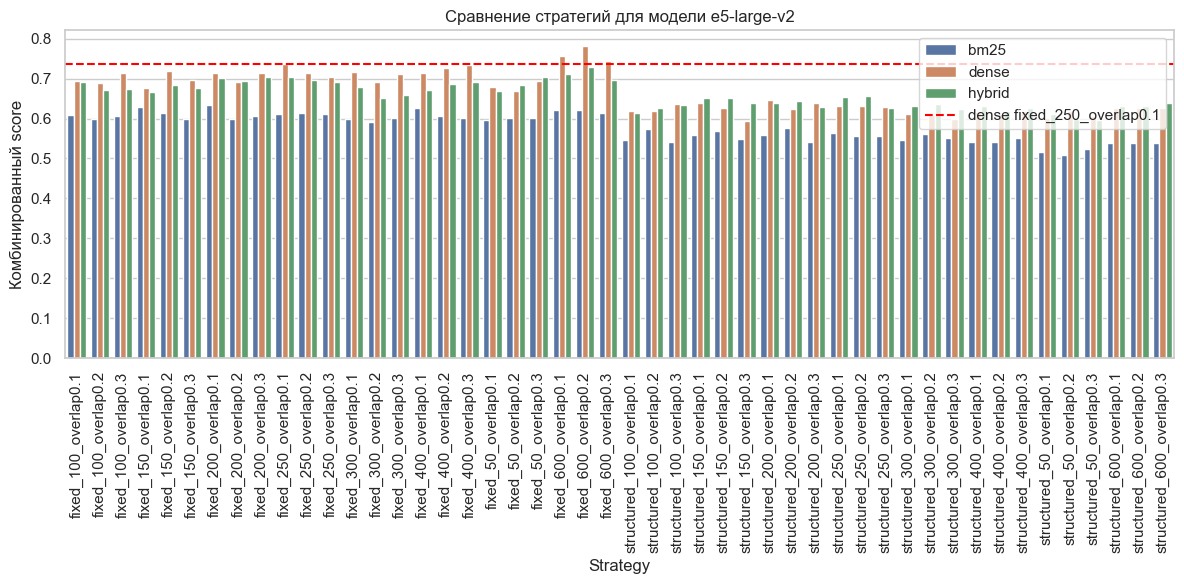

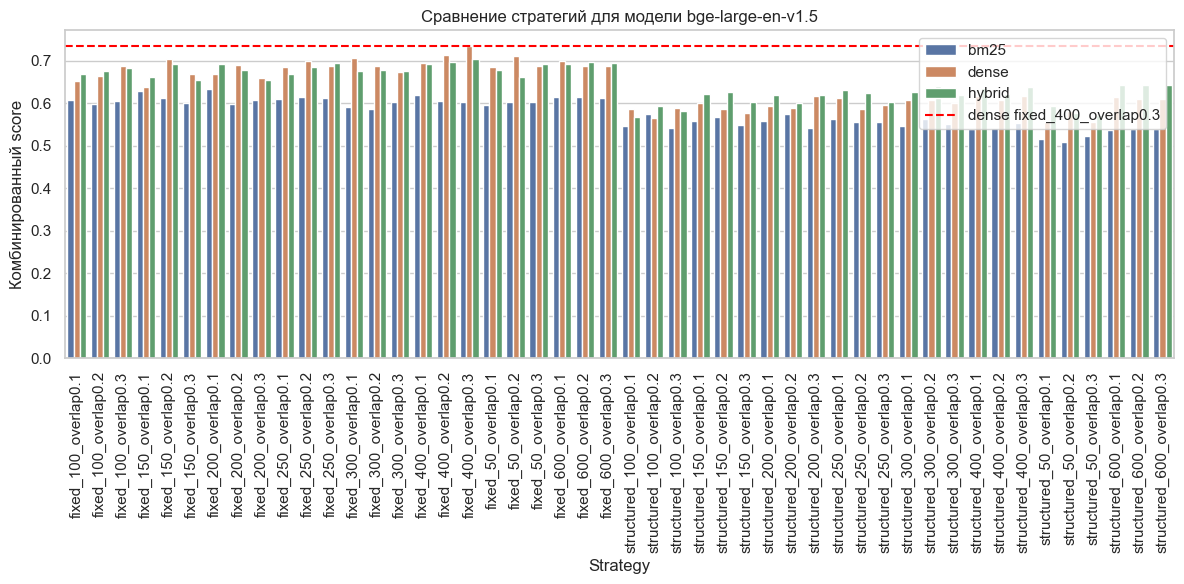

In [ ]:
import json
import os
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

folders = {
    "e5-large-v2": "metrics",
    "bge-large-en-v1.5": "metrics_bge_large_en_v_poltora"
}

data = []
for model, folder in folders.items():
    for fname in os.listdir(folder):
        if fname.endswith(".json"):
            strategy = fname.replace("metrics_", "").replace(".json", "")
            with open(os.path.join(folder, fname), "r") as f:
                metrics = json.load(f)
            for retriever, vals in metrics.items():
                score = 0.5*vals["Recall@5"] + 0.3*vals["nDCG@5"] + 0.2*vals["MRR"]
                data.append({
                    "Model": model,
                    "Strategy": strategy,
                    "Retriever": retriever,
                    "Score": score
                })

df = pd.DataFrame(data)

sns.set(style="whitegrid")

for model in df["Model"].unique():
    plt.figure(figsize=(12,6))
    subset = df[df["Model"] == model]
    sns.barplot(
        data=subset,
        x="Strategy", y="Score", hue="Retriever"
    )
    plt.title(f"Сравнение стратегий для модели {model}")
    plt.xticks(rotation=90, ha="center")
    plt.ylabel("Комбинированный score")
    plt.legend(title="Retriever")

    # --- Добавляем линии ---
    if model == "e5-large-v2":
        target = subset[(subset["Strategy"] == "fixed_250_overlap0.1") & (subset["Retriever"] == "dense")]
        if not target.empty:
            yval = target["Score"].values[0]
            plt.axhline(y=yval, color="red", linestyle="--", label="dense fixed_250_overlap0.1")
    elif model == "bge-large-en-v1.5":
        target = subset[(subset["Strategy"] == "fixed_400_overlap0.3") & (subset["Retriever"] == "dense")]
        if not target.empty:
            yval = target["Score"].values[0]
            plt.axhline(y=yval, color="red", linestyle="--", label="dense fixed_400_overlap0.3")

    plt.legend()
    plt.tight_layout()
    plt.show()


# Данный график был перегенерирован в конце ноутбука без комбинированного скора


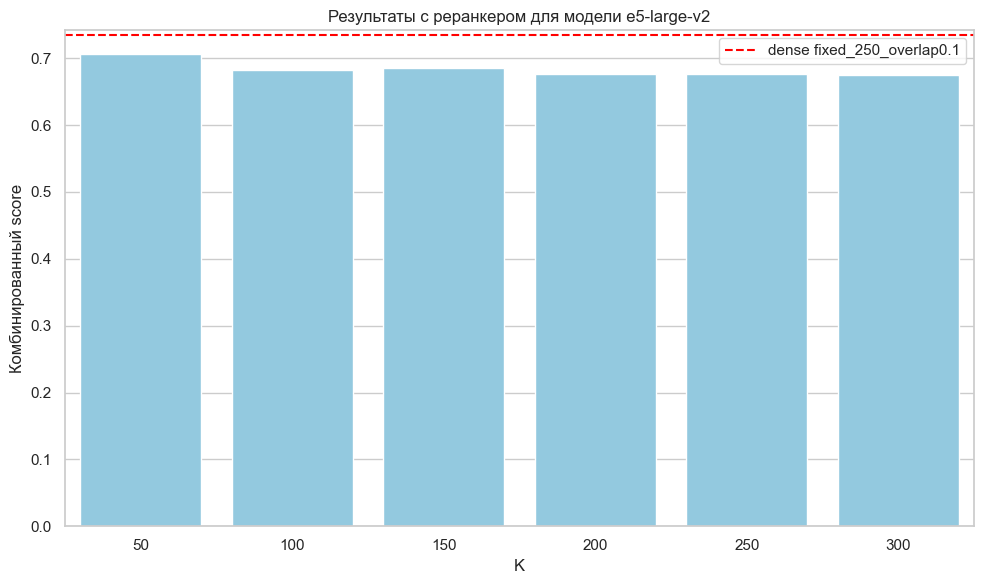

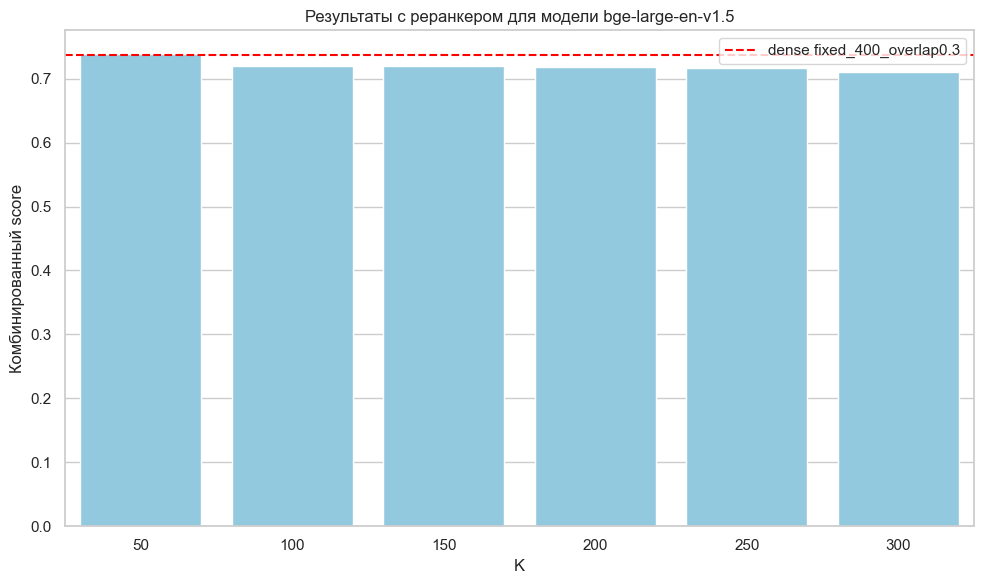

In [ ]:
import json
import os
import re
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

folders = {
    "e5-large-v2": "metrics/metrics_dense_vs_cross_enc/metrics_cross_bge_reranker",
    "bge-large-en-v1.5": "metrics_bge_large_en_v_poltora/metrics_dense_vs_cross_enc/metrics_cross_bge_reranker"
}

sns.set(style="whitegrid")

for model, folder in folders.items():
    data = []
    dense_score = None

    for fname in os.listdir(folder):
        if fname.endswith(".json"):
            # извлекаем число K из имени файла
            match = re.search(r"_k(\d+)", fname)
            if match:
                k_val = int(match.group(1))
            else:
                k_val = 300  # если явно top300

            with open(os.path.join(folder, fname), "r") as f:
                metrics = json.load(f)

            # берём dense только один раз
            if dense_score is None:
                d = metrics["dense"]
                dense_score = 0.5*d["Recall@5"] + 0.3*d["nDCG@5"] + 0.2*d["MRR"]

            # считаем score для реранкера
            r = metrics["reranker"]
            reranker_score = 0.5*r["Recall@5"] + 0.3*r["nDCG@5"] + 0.2*r["MRR"]

            data.append({"K": k_val, "Score": reranker_score})

    df = pd.DataFrame(data).sort_values("K")

    plt.figure(figsize=(10,6))
    sns.barplot(data=df, x="K", y="Score", color="skyblue")
    plt.title(f"Результаты с реранкером для модели {model}")
    plt.ylabel("Комбинированный score")

    # линия для базового dense
    if model == "e5-large-v2":
        plt.axhline(y=dense_score, color="red", linestyle="--", label="dense fixed_250_overlap0.1")
    elif model == "bge-large-en-v1.5":
        plt.axhline(y=dense_score, color="red", linestyle="--", label="dense fixed_400_overlap0.3")

    plt.legend()
    plt.tight_layout()
    plt.show()

    # Данный график был перегенерирован в конце ноутбука без комбинированного скора



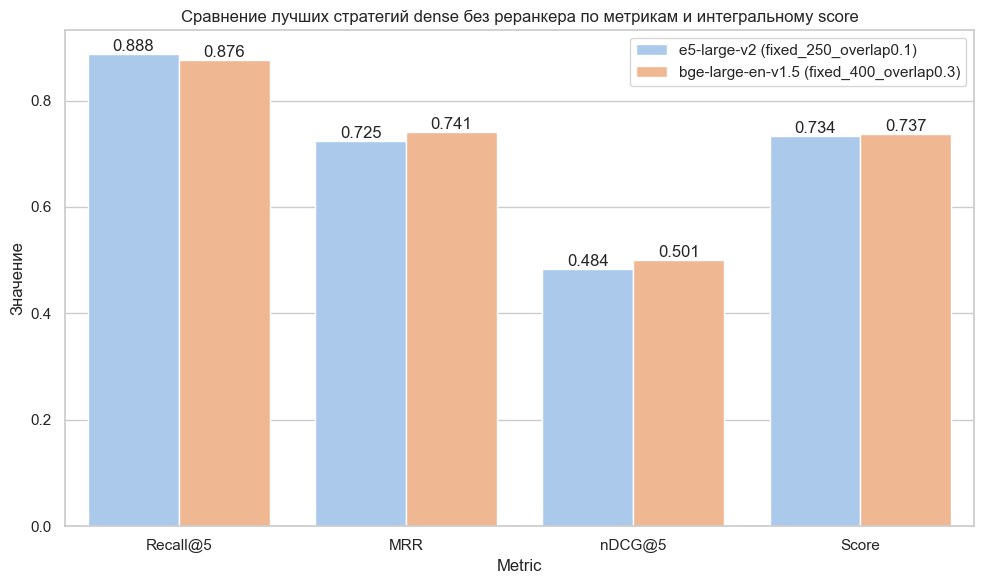

In [ ]:
import json
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

files = {
    "e5-large-v2 (fixed_250_overlap0.1)": "metrics/metrics_dense_vs_cross_enc/metrics_cross_bge_reranker/metrics_results_dense_fixed_250_overlap0.1_top300__vs__results_reranker_bge_k50__k5.json",
    "bge-large-en-v1.5 (fixed_400_overlap0.3)": "metrics_bge_large_en_v_poltora/metrics_dense_vs_cross_enc/metrics_cross_bge_reranker/metrics_results_dense_fixed_400_overlap0.3_top300__vs__results_reranker_bge_k50__k5.json"
}

data = []
for label, path in files.items():
    with open(path, "r") as f:
        metrics = json.load(f)
    d = metrics["dense"]
    score = 0.5*d["Recall@5"] + 0.3*d["nDCG@5"] + 0.2*d["MRR"]
    data.append({"Model": label, "Metric": "Recall@5", "Value": d["Recall@5"]})
    data.append({"Model": label, "Metric": "MRR", "Value": d["MRR"]})
    data.append({"Model": label, "Metric": "nDCG@5", "Value": d["nDCG@5"]})
    data.append({"Model": label, "Metric": "Score", "Value": score})

df = pd.DataFrame(data)

sns.set(style="whitegrid")
plt.figure(figsize=(10,6))
ax = sns.barplot(data=df, x="Metric", y="Value", hue="Model", palette="pastel")

# подписи над столбцами (только если значение > 0)
for p in ax.patches:
    val = p.get_height()
    if val > 0:
        ax.annotate(f"{val:.3f}",
                    (p.get_x() + p.get_width()/2., val),
                    ha="center", va="bottom")

plt.title("Сравнение лучших стратегий dense без реранкера по метрикам и интегральному score")
plt.ylabel("Значение")
plt.legend()
plt.tight_layout()
plt.show()

# Данный график был перегенерирован в конце ноутбука без комбинированного скора


### Начали делать генератор ###

In [4]:
from transformers import AutoTokenizer

model_name = "Qwen/Qwen2.5-3B-Instruct"

tokenizer = AutoTokenizer.from_pretrained(
    model_name,
    trust_remote_code=True
)

print("Tokenizer loaded!")


Tokenizer loaded!


In [ ]:
from transformers import AutoModelForCausalLM
import torch

model = AutoModelForCausalLM.from_pretrained(
    model_name,
    device_map="auto",   
    torch_dtype=torch.float16,
    trust_remote_code=True
)

print("Model loaded!")


[transformers] `torch_dtype` is deprecated! Use `dtype` instead!
Loading weights: 100%|██████████| 434/434 [00:06<00:00, 66.85it/s]


Model loaded!


### Генерация долгая - надо выбрать стратегию + ретриверы по которым сгенерить ответы чтобы потом оценивать их по новым метрикам ###

In [ ]:
import os
import json
from glob import glob

METRICS_DIR = "metrics"

def compute_integral_score(d):
    return 0.5 * d["Recall@5"] + 0.3 * d["nDCG@5"] + 0.2 * d["MRR"]

results = []

for path in glob(os.path.join(METRICS_DIR, "metrics_*.json")):
    with open(path, "r", encoding="utf-8") as f:
        data = json.load(f)

    filename = os.path.basename(path).replace(".json", "")

    for retriever_name, metrics in data.items():
        score = compute_integral_score(metrics)

        results.append({
            "strategy": filename,         
            "retriever": retriever_name,   #
            "score": score,
            "Recall@5": metrics["Recall@5"],
            "MRR": metrics["MRR"],
            "nDCG@5": metrics["nDCG@5"]
        })

# сортировка по убыванию интегрального скора
results_sorted = sorted(results, key=lambda x: x["score"], reverse=True)

print("=== RANKED STRATEGIES (BEST FIRST) ===\n")
for r in results_sorted:
    print(
        f"{r['strategy']:35s} | "
        f"{r['retriever']:7s} | "
        f"Score={r['score']:.4f} | "
        f"R@5={r['Recall@5']:.3f} | "
        f"MRR={r['MRR']:.3f} | "
        f"nDCG@5={r['nDCG@5']:.3f}"
    )


=== RANKED STRATEGIES (BEST FIRST) ===

metrics_fixed_600_overlap0.2        | dense   | Score=0.7817 | R@5=0.910 | MRR=0.773 | nDCG@5=0.573
metrics_fixed_600_overlap0.1        | dense   | Score=0.7577 | R@5=0.899 | MRR=0.737 | nDCG@5=0.536
metrics_fixed_600_overlap0.3        | dense   | Score=0.7435 | R@5=0.888 | MRR=0.717 | nDCG@5=0.521
metrics_fixed_250_overlap0.1        | dense   | Score=0.7357 | R@5=0.888 | MRR=0.719 | nDCG@5=0.493
metrics_fixed_400_overlap0.3        | dense   | Score=0.7336 | R@5=0.865 | MRR=0.722 | nDCG@5=0.522
metrics_fixed_600_overlap0.2        | hybrid  | Score=0.7281 | R@5=0.865 | MRR=0.719 | nDCG@5=0.506
metrics_fixed_400_overlap0.2        | dense   | Score=0.7256 | R@5=0.865 | MRR=0.714 | nDCG@5=0.500
metrics_fixed_150_overlap0.2        | dense   | Score=0.7184 | R@5=0.865 | MRR=0.715 | nDCG@5=0.476
metrics_fixed_300_overlap0.1        | dense   | Score=0.7159 | R@5=0.876 | MRR=0.676 | nDCG@5=0.475
metrics_fixed_400_overlap0.1        | dense   | Score=0.7148

In [21]:
# Ячейка: generate_answers_from_retrievals.py
import json
import os
from tqdm import tqdm
import re

# ==========================
# 1. Очистка контекста
# ==========================
def clean_context(text):
    # Удаляем опасные токены Qwen
    text = text.replace("<|im_start|>", "")
    text = text.replace("<|im_end|>", "")
    text = text.replace("User:", "")
    text = text.replace("Assistant:", "")
    text = text.replace("Human:", "")
    text = text.replace("###", "")

    # Удаляем кодовые блоки
    text = re.sub(r"```.*?```", "", text, flags=re.DOTALL)

    # Удаляем HTML-теги
    text = re.sub(r"<[^>]+>", " ", text)

    # Удаляем markdown-картинки
    text = re.sub(r"!\[.*?\]\(.*?\)", " ", text)

    # Удаляем markdown-ссылки
    text = re.sub(r"\[([^\]]+)\]\([^)]+\)", r"\1", text)

    # Удаляем таблицы
    text = "\n".join(
        line for line in text.splitlines()
        if not re.match(r"^\s*\|.*\|\s*$", line)
    )

    # Убираем лишние пробелы
    text = re.sub(r"\s+", " ", text)

    return text.strip()


# ==========================
# 2. Загрузка чанков
# ==========================
def load_chunks(chunks_path):
    chunks = {}
    with open(chunks_path, "r", encoding="utf-8") as f:
        for line in f:
            item = json.loads(line)
            cid = item.get("chunk_id") or item.get("id") or item.get("id_chunk")
            if not cid:
                continue
            chunks[cid] = item.get("text", "")
    return chunks


# ==========================
# 3. Построение контекста
# ==========================
def build_context_from_retrieved(retrieved_list, chunks_map, top_k=5, max_chars=None):
    ctx_parts = []
    for r in retrieved_list[:top_k]:
        cid = r.get("chunk_id")
        text = chunks_map.get(cid)
        if text:
            ctx_parts.append(f"--- CHUNK {cid} ---\n{text}\n")

    context = "\n".join(ctx_parts).strip()

    if max_chars and len(context) > max_chars:
        half = max_chars // 2
        context = context[:half] + "\n...\n" + context[-half:]

    return clean_context(context)


# ==========================
# 4. Генерация ответа (Qwen-safe)
# ==========================
def generate_rag_answer_local(
    model,
    tokenizer,
    query,
    context,
    max_new_tokens=150,
    temperature=0.0,
):
    # Очистка вопроса от опасных токенов
    query = (
        query.replace("<|im_start|>", "")
             .replace("<|im_end|>", "")
             .replace("###", "")
             .replace("User:", "")
             .replace("Assistant:", "")
             .replace("Human:", "")
    )

    # Qwen chat format
    prompt = (
        "<|im_start|>system\n"
        "You are an assistant that answers ONLY using the provided context.\n"
        "Write a short, factual answer.\n"
        "Do NOT continue the conversation.\n"
        "Do NOT ask questions.\n"
        "Do NOT add examples.\n"
        "Do NOT add disclaimers.\n"
        "Stop immediately after the answer.\n"
        "<|im_end|>\n"
        "<|im_start|>user\n"
        f"Context:\n{context}\n\n"
        f"Question:\n{query}\n"
        "<|im_end|>\n"
        "<|im_start|>assistant\n"
    )

    inputs = tokenizer(prompt, return_tensors="pt").to(model.device)

    out = model.generate(
        **inputs,
        max_new_tokens=max_new_tokens,
        do_sample=False,
        temperature=temperature,
        eos_token_id=tokenizer.convert_tokens_to_ids("<|im_end|>"),
        pad_token_id=tokenizer.eos_token_id,
    )

    text = tokenizer.decode(out[0], skip_special_tokens=False)

    # Извлекаем только ответ ассистента
    answer = text.split("<|im_start|>assistant")[-1]
    answer = answer.split("<|im_end|>")[0].strip()

    return answer


# ==========================
# 5. Генерация по файлу
# ==========================
def generate_answers_for_strategy(
    retrievals_path,
    chunks_path,
    out_jsonl,
    model,
    tokenizer,
    top_k=5,
    max_context_chars=None,
    max_new_tokens=150,
    temperature=0.0
):
    chunks_map = load_chunks(chunks_path)
    os.makedirs(os.path.dirname(out_jsonl) or ".", exist_ok=True)

    with open(retrievals_path, "r", encoding="utf-8") as fin, \
         open(out_jsonl, "w", encoding="utf-8") as fout:

        for line in tqdm(fin, desc=f"Gen from {os.path.basename(retrievals_path)}"):
            item = json.loads(line)

            query = item.get("query")
            retrieved = item.get("retrieved", [])
            qid = item.get("id") or item.get("query")[:120]

            context = build_context_from_retrieved(
                retrieved,
                chunks_map,
                top_k=top_k,
                max_chars=max_context_chars
            )

            answer = generate_rag_answer_local(
                model=model,
                tokenizer=tokenizer,
                query=query,
                context=context,
                max_new_tokens=max_new_tokens,
                temperature=temperature
            )

            out = {
                "id": qid,
                "query": query,
                "retrieved": retrieved[:top_k],
                "context": context,
                "answer": answer
            }

            fout.write(json.dumps(out, ensure_ascii=False) + "\n")

    print("Generation finished, saved to", out_jsonl)


In [ ]:
# === ТЕСТ ГЕНЕРАЦИИ ДЛЯ ОДНОГО КОНКРЕТНОГО ВОПРОСА ===

chunks_path = "chunks/chunks_fixed_250_overlap0.1.jsonl"
retrievals_path = "results/results_dense/results_dense_fixed_250_overlap0.1.jsonl"

chunks_map = load_chunks(chunks_path)

target_query_text = "how can users interact with provider models"

test_query = None
test_retrieved = None

with open(retrievals_path, "r", encoding="utf-8") as f:
    for line in f:
        item = json.loads(line)
        if target_query_text.lower() in item["query"].lower():
            test_query = item["query"]
            test_retrieved = item["retrieved"]
            break

if test_query is None:
    print("❌ Вопрос не найден в retrieval-файле!")
else:
    print("Тестовый вопрос:", test_query)

    context = build_context_from_retrieved(
        test_retrieved,
        chunks_map,
        top_k=5,
        max_chars=4000
    )

    print("\n=== Контекст ===\n")
    print(context[:1500], "...\n")

    answer = generate_rag_answer_local(
        model=model,
        tokenizer=tokenizer,
        query=test_query,
        context=context,
        max_new_tokens=150,
        temperature=0.0
    )

    print("\n=== Ответ модели ===\n")
    print(answer)


Тестовый вопрос: how can users interact with provider models?

=== Контекст ===

--- CHUNK creating-new-model-provider.mdx_chunk_2 --- determine how users will interact with your provider's models: ### Predefined Models (`predefined-model`) These are models that only require unified provider credentials to use. Once a user configures their API key or other authentication details for the provider, they can immediately access all predefined models. **Example:** The `OpenAI` provider offers predefined models like `gpt-3.5-turbo-0125` and `gpt-4o-2024-05-13`. A user only needs to configure their OpenAI API key once to access all these models. ### Custom Models (`customizable-model`) These require additional configuration for each specific model instance. This approach is useful when models need individual parameters beyond the provider-level credentials. **Example:** `Xinference` supports both LLM and Text Embedding, but each model has a unique **model_uid**. Users must configure this mode

## заново запустим пакетку ##


In [23]:
# === Автоматический запуск генерации для выбранных стратегий ===

strategies = [
    # ----- fixed / dense -----
    {
        "name": "fixed_600_overlap0.2_dense",
        "retrievals": "results/results_dense/results_dense_fixed_600_overlap0.2.jsonl",
        "chunks":     "chunks/chunks_fixed_600_overlap0.2.jsonl",
        "out":        "rag_outputs/answers_fixed_600_overlap0.2_dense.jsonl"
    },
    {
        "name": "fixed_250_overlap0.1_dense",
        "retrievals": "results/results_dense/results_dense_fixed_250_overlap0.1.jsonl",
        "chunks":     "chunks/chunks_fixed_250_overlap0.1.jsonl",
        "out":        "rag_outputs/answers_fixed_250_overlap0.1_dense.jsonl"
    },
    {
        "name": "fixed_400_overlap0.3_dense",
        "retrievals": "results/results_dense/results_dense_fixed_400_overlap0.3.jsonl",
        "chunks":     "chunks/chunks_fixed_400_overlap0.3.jsonl",
        "out":        "rag_outputs/answers_fixed_400_overlap0.3_dense.jsonl"
    },
    {
        "name": "fixed_150_overlap0.2_dense",
        "retrievals": "results/results_dense/results_dense_fixed_150_overlap0.2.jsonl",
        "chunks":     "chunks/chunks_fixed_150_overlap0.2.jsonl",
        "out":        "rag_outputs/answers_fixed_150_overlap0.2_dense.jsonl"
    },
    {
        "name": "fixed_300_overlap0.1_dense",
        "retrievals": "results/results_dense/results_dense_fixed_300_overlap0.1.jsonl",
        "chunks":     "chunks/chunks_fixed_300_overlap0.1.jsonl",
        "out":        "rag_outputs/answers_fixed_300_overlap0.1_dense.jsonl"
    },
    {
        "name": "fixed_200_overlap0.1_dense",
        "retrievals": "results/results_dense/results_dense_fixed_200_overlap0.1.jsonl",
        "chunks":     "chunks/chunks_fixed_200_overlap0.1.jsonl",
        "out":        "rag_outputs/answers_fixed_200_overlap0.1_dense.jsonl"
    },
    {
        "name": "fixed_100_overlap0.3_dense",
        "retrievals": "results/results_dense/results_dense_fixed_100_overlap0.3.jsonl",
        "chunks":     "chunks/chunks_fixed_100_overlap0.3.jsonl",
        "out":        "rag_outputs/answers_fixed_100_overlap0.3_dense.jsonl"
    },

    # ----- fixed / hybrid -----
    {
        "name": "fixed_600_overlap0.2_hybrid",
        "retrievals": "results/results_hybrid/results_hybrid_fixed_600_overlap0.2.jsonl",
        "chunks":     "chunks/chunks_fixed_600_overlap0.2.jsonl",
        "out":        "rag_outputs/answers_fixed_600_overlap0.2_hybrid.jsonl"
    },
    {
        "name": "fixed_50_overlap0.3_hybrid",
        "retrievals": "results/results_hybrid/results_hybrid_fixed_50_overlap0.3.jsonl",
        "chunks":     "chunks/chunks_fixed_50_overlap0.3.jsonl",
        "out":        "rag_outputs/answers_fixed_50_overlap0.3_hybrid.jsonl"
    },
    {
        "name": "fixed_200_overlap0.1_hybrid",
        "retrievals": "results/results_hybrid/results_hybrid_fixed_200_overlap0.1.jsonl",
        "chunks":     "chunks/chunks_fixed_200_overlap0.1.jsonl",
        "out":        "rag_outputs/answers_fixed_200_overlap0.1_hybrid.jsonl"
    },
    {
        "name": "fixed_250_overlap0.2_hybrid",
        "retrievals": "results/results_hybrid/results_hybrid_fixed_250_overlap0.2.jsonl",
        "chunks":     "chunks/chunks_fixed_250_overlap0.2.jsonl",
        "out":        "rag_outputs/answers_fixed_250_overlap0.2_hybrid.jsonl"
    },

    # ----- structured / hybrid -----
    {
        "name": "structured_250_overlap0.2_hybrid",
        "retrievals": "results/results_hybrid/results_hybrid_structured_250_overlap0.2.jsonl",
        "chunks":     "chunks/chunks_structured_250_overlap0.2.jsonl",
        "out":        "rag_outputs/answers_structured_250_overlap0.2_hybrid.jsonl"
    },
    {
        "name": "structured_150_overlap0.2_hybrid",
        "retrievals": "results/results_hybrid/results_hybrid_structured_150_overlap0.2.jsonl",
        "chunks":     "chunks/chunks_structured_150_overlap0.2.jsonl",
        "out":        "rag_outputs/answers_structured_150_overlap0.2_hybrid.jsonl"
    },
    {
        "name": "structured_600_overlap0.3_hybrid",
        "retrievals": "results/results_hybrid/results_hybrid_structured_600_overlap0.3.jsonl",
        "chunks":     "chunks/chunks_structured_600_overlap0.3.jsonl",
        "out":        "rag_outputs/answers_structured_600_overlap0.3_hybrid.jsonl"
    },
    {
        "name": "structured_300_overlap0.2_hybrid",
        "retrievals": "results/results_hybrid/results_hybrid_structured_300_overlap0.2.jsonl",
        "chunks":     "chunks/chunks_structured_300_overlap0.2.jsonl",
        "out":        "rag_outputs/answers_structured_300_overlap0.2_hybrid.jsonl"
    },

    # ----- structured / dense -----
    {
        "name": "structured_200_overlap0.1_dense",
        "retrievals": "results/results_dense/results_dense_structured_200_overlap0.1.jsonl",
        "chunks":     "chunks/chunks_structured_200_overlap0.1.jsonl",
        "out":        "rag_outputs/answers_structured_200_overlap0.1_dense.jsonl"
    },
    {
        "name": "structured_150_overlap0.1_dense",
        "retrievals": "results/results_dense/results_dense_structured_150_overlap0.1.jsonl",
        "chunks":     "chunks/chunks_structured_150_overlap0.1.jsonl",
        "out":        "rag_outputs/answers_structured_150_overlap0.1_dense.jsonl"
    },
    {
        "name": "structured_100_overlap0.3_dense",
        "retrievals": "results/results_dense/results_dense_structured_100_overlap0.3.jsonl",
        "chunks":     "chunks/chunks_structured_100_overlap0.3.jsonl",
        "out":        "rag_outputs/answers_structured_100_overlap0.3_dense.jsonl"
    }
]

for s in strategies:
    print(f"\n=== Generating for {s['name']} ===")
    generate_answers_for_strategy(
        retrievals_path=s["retrievals"],
        chunks_path=s["chunks"],
        out_jsonl=s["out"],
        model=model,
        tokenizer=tokenizer,
        top_k=5,
        max_context_chars=8000,
        max_new_tokens=180,
        temperature=0.0
    )



=== Generating for fixed_600_overlap0.2_dense ===


Gen from results_dense_fixed_600_overlap0.2.jsonl: 89it [1:20:11, 54.06s/it]


Generation finished, saved to rag_outputs/answers_fixed_600_overlap0.2_dense.jsonl

=== Generating for fixed_250_overlap0.1_dense ===


Gen from results_dense_fixed_250_overlap0.1.jsonl: 89it [1:14:24, 50.16s/it] 


Generation finished, saved to rag_outputs/answers_fixed_250_overlap0.1_dense.jsonl

=== Generating for fixed_400_overlap0.3_dense ===


...

Generation finished, saved to rag_outputs/answers_structured_200_overlap0.1_dense.jsonl

=== Generating for structured_150_overlap0.1_dense ===


Gen from results_dense_structured_150_overlap0.1.jsonl: 89it [1:06:36, 44.91s/it]


Generation finished, saved to rag_outputs/answers_structured_150_overlap0.1_dense.jsonl

=== Generating for structured_100_overlap0.3_dense ===


Gen from results_dense_structured_100_overlap0.3.jsonl: 89it [1:01:53, 41.73s/it]

Generation finished, saved to rag_outputs/answers_structured_100_overlap0.3_dense.jsonl


### Теперь посчитаем BLEU / ROUGE‑L / BERTScore ###

In [26]:
import os
import json
import csv
from glob import glob
from pathlib import Path

import nltk
nltk.download('punkt', quiet=True)

from nltk.tokenize import word_tokenize
from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction
from rouge_score import rouge_scorer

from bert_score import score as bert_score
import torch

# ----------------- Параметры -----------------
GOLDEN_PATH = "golden_master.json"
ANSWERS_GLOB = "rag_outputs/*.jsonl"
OUT_DIR = "eval_text_metrics_BLEU_ROUGEL_BERTScore"
os.makedirs(OUT_DIR, exist_ok=True)

# ОДНА модель для всех файлов — поддерживаемая BERTScore
BERTSCORE_MODEL = "distilbert-base-uncased"

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", device)

# ----------------- Загрузка golden -----------------
gold_map = {}
with open(GOLDEN_PATH, "r", encoding="utf-8") as f:
    data = json.load(f)
    for item in data:
        q = (item.get("query") or "").strip()
        gold = item.get("gold_answer") or item.get("expected_answer") or item.get("answer")
        if q and gold:
            gold_map[q.lower()] = gold.strip()
print(f"Loaded {len(gold_map)} golden entries from {GOLDEN_PATH}")

# ----------------- Инициализация метрик -----------------
rouge = rouge_scorer.RougeScorer(["rougeL"], use_stemmer=True)
smooth = SmoothingFunction().method1

summary_rows = []

# ----------------- Основной цикл по файлам ответов -----------------
for answers_path in sorted(glob(ANSWERS_GLOB)):
    basename = os.path.basename(answers_path)
    out_csv = os.path.join(OUT_DIR, basename.replace(".jsonl", "_metrics.csv"))
    out_jsonl = os.path.join(OUT_DIR, basename.replace(".jsonl", "_metrics.jsonl"))

    raw_items = []
    answers = []
    golds = []

    # Загружаем файл с ответами
    with open(answers_path, "r", encoding="utf-8") as fin:
        for line in fin:
            item = json.loads(line)
            qid = (item.get("id") or "").strip()
            query = (item.get("query") or "").strip()
            answer = (item.get("answer") or "").strip()

            qid_norm = qid.lower()
            query_norm = query.lower()

            gold = None
            if qid_norm in gold_map:
                gold = gold_map[qid_norm]
            elif query_norm in gold_map:
                gold = gold_map[query_norm]

            raw_items.append({"id": qid or query, "query": query, "answer": answer, "gold": gold})

            if gold is not None:
                answers.append(answer)
                golds.append(gold)

    if not answers:
        print(f"No matched pairs found in {answers_path} — пропускаем.")
        continue

    # ----------------- BERTScore -----------------
    print(f"Computing BERTScore for {basename} using {BERTSCORE_MODEL}")
    P, R, F1 = bert_score(
        answers,
        golds,
        model_type=BERTSCORE_MODEL,
        lang="en",
        device=device,
        verbose=False,
        rescale_with_baseline=False
    )
    bert_f1_list = [float(x) for x in F1]

    # ----------------- BLEU/ROUGE + сбор -----------------
    rows = []
    bert_idx = 0

    for rec in raw_items:
        if rec["gold"] is None:
            rows.append({
                "id": rec["id"],
                "query": rec["query"],
                "bleu": None,
                "rougeL": None,
                "bertscore_f1": None,
                "note": "no_gold"
            })
            continue

        ans = rec["answer"]
        gold = rec["gold"]

        ref_tokens = word_tokenize(gold)
        hyp_tokens = word_tokenize(ans)

        try:
            bleu = sentence_bleu([ref_tokens], hyp_tokens, smoothing_function=smooth)
        except Exception:
            bleu = 0.0

        try:
            rouge_l = rouge.score(gold, ans)["rougeL"].fmeasure
        except Exception:
            rouge_l = 0.0

        bert_f1 = bert_f1_list[bert_idx]
        bert_idx += 1

        rows.append({
            "id": rec["id"],
            "query": rec["query"],
            "bleu": bleu,
            "rougeL": rouge_l,
            "bertscore_f1": bert_f1,
            "note": None
        })

    # ----------------- Сохранение -----------------
    with open(out_csv, "w", encoding="utf-8", newline="") as fcsv:
        writer = csv.writer(fcsv)
        writer.writerow(["id", "query", "bleu", "rougeL", "bertscore_f1", "note"])
        for r in rows:
            writer.writerow([r["id"], r["query"], r["bleu"], r["rougeL"], r["bertscore_f1"], r["note"]])

    with open(out_jsonl, "w", encoding="utf-8") as fout:
        for r in rows:
            fout.write(json.dumps(r, ensure_ascii=False) + "\n")

    # ----------------- Агрегаты -----------------
    bleu_vals = [r["bleu"] for r in rows if r["bleu"] is not None]
    rouge_vals = [r["rougeL"] for r in rows if r["rougeL"] is not None]
    bert_vals = [r["bertscore_f1"] for r in rows if r["bertscore_f1"] is not None]

    bleu_mean = sum(bleu_vals) / len(bleu_vals)
    rouge_mean = sum(rouge_vals) / len(rouge_vals)
    bert_mean = sum(bert_vals) / len(bert_vals)

    print(f"Evaluated {basename}: BLEU={bleu_mean:.4f}, ROUGE-L={rouge_mean:.4f}, BERT-F1={bert_mean:.4f}")


Using device: cuda
Loaded 89 golden entries from golden_master.json
Computing BERTScore for answers_fixed_100_overlap0.3_dense.jsonl using distilbert-base-uncased


Loading weights: 100%|██████████| 100/100 [00:00<00:00, 5133.03it/s]
[transformers] DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_layer_norm.bias   | UNEXPECTED |  | 
vocab_transform.weight  | UNEXPECTED |  | 
vocab_projector.bias    | UNEXPECTED |  | 
vocab_layer_norm.weight | UNEXPECTED |  | 
vocab_transform.bias    | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Evaluated answers_fixed_100_overlap0.3_dense.jsonl: BLEU=0.1046, ROUGE-L=0.3439, BERT-F1=0.8432
Computing BERTScore for answers_fixed_150_overlap0.2_dense.jsonl using distilbert-base-uncased


Loading weights: 100%|██████████| 100/100 [00:00<00:00, 7531.79it/s]
[transformers] DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_layer_norm.bias   | UNEXPECTED |  | 
vocab_transform.weight  | UNEXPECTED |  | 
vocab_projector.bias    | UNEXPECTED |  | 
vocab_layer_norm.weight | UNEXPECTED |  | 
vocab_transform.bias    | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Evaluated answers_fixed_150_overlap0.2_dense.jsonl: BLEU=0.1013, ROUGE-L=0.3388, BERT-F1=0.8403
Computing BERTScore for answers_fixed_200_overlap0.1_dense.jsonl using distilbert-base-uncased


...

Evaluated answers_structured_250_overlap0.2_hybrid.jsonl: BLEU=0.1157, ROUGE-L=0.3587, BERT-F1=0.8486
Computing BERTScore for answers_structured_300_overlap0.2_hybrid.jsonl using distilbert-base-uncased


Loading weights: 100%|██████████| 100/100 [00:00<00:00, 7669.09it/s]
[transformers] DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_layer_norm.bias   | UNEXPECTED |  | 
vocab_transform.weight  | UNEXPECTED |  | 
vocab_projector.bias    | UNEXPECTED |  | 
vocab_layer_norm.weight | UNEXPECTED |  | 
vocab_transform.bias    | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Evaluated answers_structured_300_overlap0.2_hybrid.jsonl: BLEU=0.1145, ROUGE-L=0.3496, BERT-F1=0.8465
Computing BERTScore for answers_structured_600_overlap0.3_hybrid.jsonl using distilbert-base-uncased


Loading weights: 100%|██████████| 100/100 [00:00<00:00, 6810.81it/s]
[transformers] DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_layer_norm.bias   | UNEXPECTED |  | 
vocab_transform.weight  | UNEXPECTED |  | 
vocab_projector.bias    | UNEXPECTED |  | 
vocab_layer_norm.weight | UNEXPECTED |  | 
vocab_transform.bias    | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Evaluated answers_structured_600_overlap0.3_hybrid.jsonl: BLEU=0.1139, ROUGE-L=0.3484, BERT-F1=0.8450


### Посмотрим на каких из выбранных страт лучше всего генерация ###

In [6]:
import os
import json
import csv
import pandas as pd
from glob import glob

METRICS_DIR = "eval_text_metrics_BLEU_ROUGEL_BERTScore"

# Собираем все CSV-файлы
csv_files = sorted(glob(os.path.join(METRICS_DIR, "*_metrics.csv")))

rows = []

for path in csv_files:
    basename = os.path.basename(path)
    
    # имя стратегии = имя файла без "_metrics.csv"
    strategy = basename.replace("_metrics.csv", "")
    
    df = pd.read_csv(path)
    
    # фильтруем строки без gold
    df_valid = df[df["note"].isna()]
    
    if len(df_valid) == 0:
        print(f"⚠ Нет валидных пар в {basename}")
        continue
    
    bleu_mean = df_valid["bleu"].mean()
    rouge_mean = df_valid["rougeL"].mean()
    bert_mean = df_valid["bertscore_f1"].mean()
    
    rows.append({
        "strategy": strategy,
        "n_pairs": len(df_valid),
        "BLEU_mean": bleu_mean,
        "ROUGE-L_mean": rouge_mean,
        "BERTScore_mean": bert_mean
    })

# Собираем всё в один DataFrame
summary = pd.DataFrame(rows)

# Ранжируем по BERTScore (главная метрика)
summary_sorted = summary.sort_values(by="BERTScore_mean", ascending=False)

print("=== Итоговый рейтинг стратегий (по BERTScore) ===")
display(summary_sorted)

# Сохраняем
summary_path = os.path.join(METRICS_DIR, "FINAL_STRATEGY_RANKING.csv")
summary_sorted.to_csv(summary_path, index=False)

print("Сводный рейтинг сохранён в:", summary_path)


=== Итоговый рейтинг стратегий (по BERTScore) ===


,strategy,n_pairs,BLEU_mean,ROUGE-L_mean,BERTScore_mean
7,answers_fixed_400_overlap0.3_dense,89,0.123749,0.372772,0.852055
4,answers_fixed_250_overlap0.1_dense,89,0.124036,0.380394,0.849793
15,answers_structured_250_overlap0.2_hybrid,89,0.115679,0.358679,0.848646
5,answers_fixed_250_overlap0.2_hybrid,89,0.117406,0.362464,0.847662
3,answers_fixed_200_overlap0.1_hybrid,89,0.108982,0.365773,0.846954
10,answers_fixed_600_overlap0.2_hybrid,89,0.110349,0.358146,0.846570
16,answers_structured_300_overlap0.2_hybrid,89,0.114456,0.349588,0.846452
6,answers_fixed_300_overlap0.1_dense,89,0.120039,0.354302,0.846213
17,answers_structured_600_overlap0.3_hybrid,89,0.113948,0.348356,0.844974
13,answers_structured_150_overlap0.2_hybrid,89,0.105361,0.347592,0.843741


Сводный рейтинг сохранён в: eval_text_metrics_BLEU_ROUGEL_BERTScore\FINAL_STRATEGY_RANKING.csv


In [1]:
import json
import re
from pathlib import Path
import tiktoken

# ============================
# Очистка текста
# ============================
def clean_context(text):
    text = text.replace("<|im_start|>", "")
    text = text.replace("<|im_end|>", "")
    text = text.replace("User:", "")
    text = text.replace("Assistant:", "")
    text = text.replace("Human:", "")
    text = text.replace("###", "")

    # Удаляем кодовые блоки
    text = re.sub(r"```.*?```", "", text, flags=re.DOTALL)

    # Удаляем HTML-теги
    text = re.sub(r"<[^>]+>", " ", text)

    # Удаляем markdown-картинки
    text = re.sub(r"!\[.*?\]\(.*?\)", " ", text)

    # Удаляем markdown-ссылки
    text = re.sub(r"\[([^\]]+)\]\([^)]+\)", r"\1", text)

    # Удаляем таблицы
    text = "\n".join(
        line for line in text.splitlines()
        if not re.match(r"^\s*\|.*\|\s*$", line)
    )

    # Убираем лишние пробелы
    text = re.sub(r"\s+", " ", text)

    return text.strip()


# ============================
# Токенизация
# ============================
enc = tiktoken.get_encoding("cl100k_base")

def encode_tokens(text):
    return enc.encode(text)

def decode_tokens(tokens):
    if not tokens:
        return ""
    if not isinstance(tokens, list):
        return ""
    if not all(isinstance(t, int) for t in tokens):
        return ""
    return enc.decode(tokens)


# ============================
# Fixed‑чанкинг
# ============================
def chunk_tokens(tokens, chunk_size, overlap):
    if not tokens:
        return []

    chunks = []
    start = 0

    while start < len(tokens):
        end = start + chunk_size
        chunk = tokens[start:end]

        if not isinstance(chunk, list):
            chunk = list(chunk)

        chunks.append(chunk)
        start = start + chunk_size - overlap

    return chunks


# ============================
# Основная функция
# ============================
def make_clean_fixed_chunks(
    chunk_size=400,
    overlap_ratio=0.3,
    input_path="parsed_structure.jsonl",
    output_path="chunks_fixed_400_overlap0.3_clean.jsonl"
):
    overlap = int(chunk_size * overlap_ratio)

    total_docs = 0
    total_chunks = 0

    with open(input_path, "r", encoding="utf-8") as f_in, \
         open(output_path, "w", encoding="utf-8") as f_out:

        for line in f_in:
            entry = json.loads(line)
            total_docs += 1

            raw_text = entry["raw_text"]
            cleaned_text = clean_context(raw_text)

            tokens = encode_tokens(cleaned_text)
            token_chunks = chunk_tokens(tokens, chunk_size, overlap)

            for idx, chunk in enumerate(token_chunks):
                f_out.write(json.dumps({
                    "chunk_id": f"{entry['file_name']}_chunk_{idx}",
                    "text": decode_tokens(chunk),
                    "file_path": entry["file_path"],
                    "relative_path": entry["relative_path"],
                    "headers": entry["headers"],
                    "hierarchy": entry["hierarchy"],
                    "section_title": None,
                    "chunk_index": idx,
                    "total_chunks": len(token_chunks)
                }, ensure_ascii=False) + "\n")

            total_chunks += len(token_chunks)

    print(f"[DONE] Processed documents: {total_docs}")
    print(f"[DONE] Generated chunks: {total_chunks}")
    print(f"[DONE] Saved to: {output_path}")


# ============================
# Запуск
# ============================
make_clean_fixed_chunks()


[DONE] Processed documents: 161
[DONE] Generated chunks: 546
[DONE] Saved to: chunks_fixed_400_overlap0.3_clean.jsonl


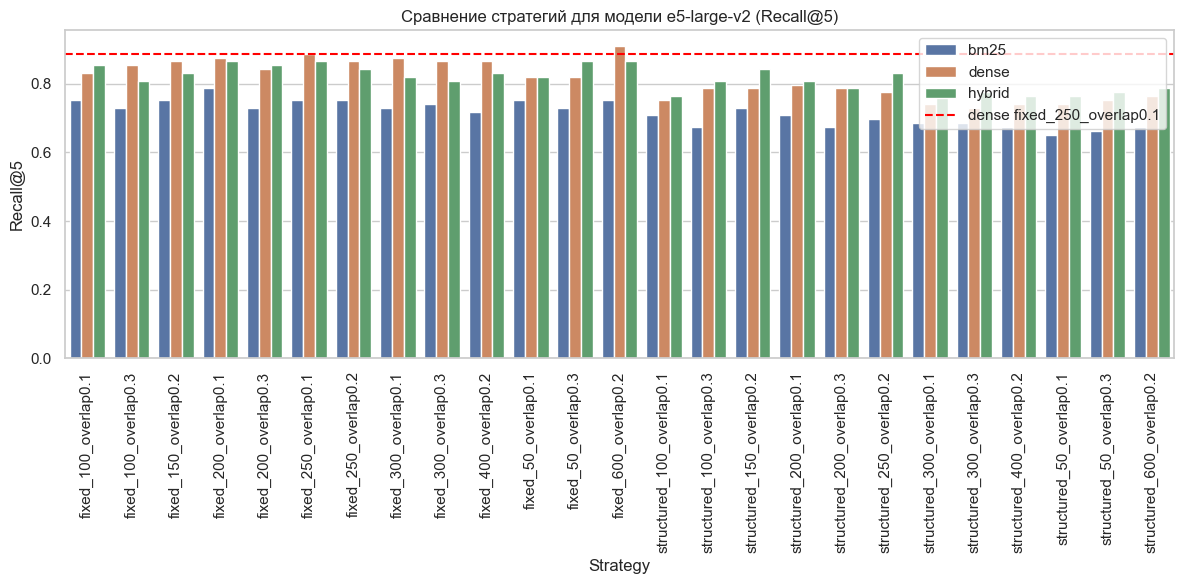

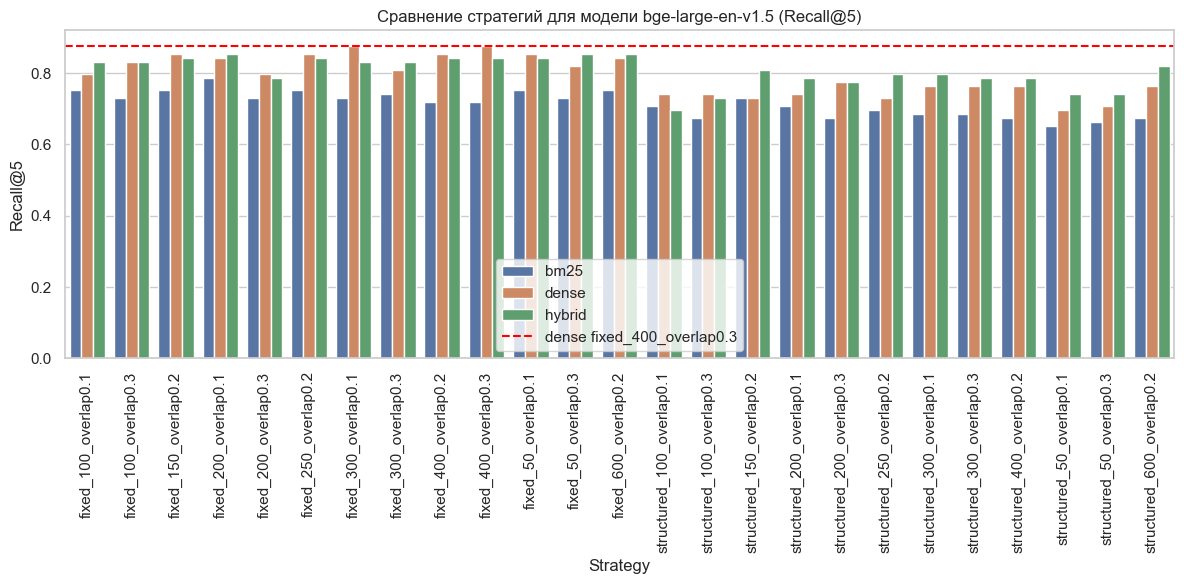

In [1]:
import json
import os
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

folders = {
    "e5-large-v2": "metrics",
    "bge-large-en-v1.5": "metrics_bge_large_en_v_poltora"
}

data = []
for model, folder in folders.items():
    for fname in os.listdir(folder):
        if fname.endswith(".json"):
            strategy = fname.replace("metrics_", "").replace(".json", "")
            with open(os.path.join(folder, fname), "r") as f:
                metrics = json.load(f)
            for retriever, vals in metrics.items():

                # 🔥 ТЕПЕРЬ ТОЛЬКО ОДНА МЕТРИКА
                score = vals["Recall@5"]

                data.append({
                    "Model": model,
                    "Strategy": strategy,
                    "Retriever": retriever,
                    "Score": score
                })

df = pd.DataFrame(data)

# -----------------------------
# 🔥 ФИЛЬТРАЦИЯ: оставляем стратегии через одну
# -----------------------------

filtered_df = pd.DataFrame()

for model in df["Model"].unique():
    subset = df[df["Model"] == model]

    strategies = sorted(subset["Strategy"].unique())
    reduced = strategies[::2]

    if model == "e5-large-v2":
        must_keep = "fixed_250_overlap0.1"
    else:
        must_keep = "fixed_400_overlap0.3"

    if must_keep not in reduced:
        reduced.append(must_keep)

    filtered_df = pd.concat([filtered_df, subset[subset["Strategy"].isin(reduced)]])

df = filtered_df.reset_index(drop=True)

# -----------------------------
# 🔥 ВИЗУАЛИЗАЦИЯ
# -----------------------------

sns.set(style="whitegrid")

for model in df["Model"].unique():
    plt.figure(figsize=(12,6))
    subset = df[df["Model"] == model]

    sns.barplot(
        data=subset,
        x="Strategy", y="Score", hue="Retriever"
    )

    plt.title(f"Сравнение стратегий для модели {model} (Recall@5)")
    plt.xticks(rotation=90, ha="center")
    plt.ylabel("Recall@5")
    plt.legend(title="Retriever")

    # --- Добавляем линии ---
    if model == "e5-large-v2":
        target = subset[(subset["Strategy"] == "fixed_250_overlap0.1") & (subset["Retriever"] == "dense")]
        if not target.empty:
            yval = target["Score"].values[0]
            plt.axhline(y=yval, color="red", linestyle="--", label="dense fixed_250_overlap0.1")

    elif model == "bge-large-en-v1.5":
        target = subset[(subset["Strategy"] == "fixed_400_overlap0.3") & (subset["Retriever"] == "dense")]
        if not target.empty:
            yval = target["Score"].values[0]
            plt.axhline(y=yval, color="red", linestyle="--", label="dense fixed_400_overlap0.3")

    plt.legend()
    plt.tight_layout()
    plt.show()


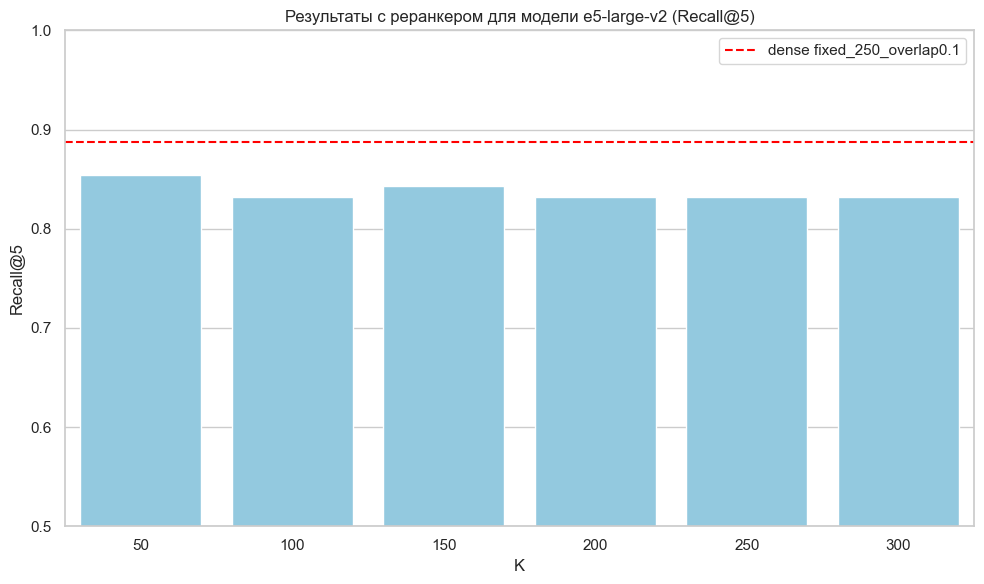

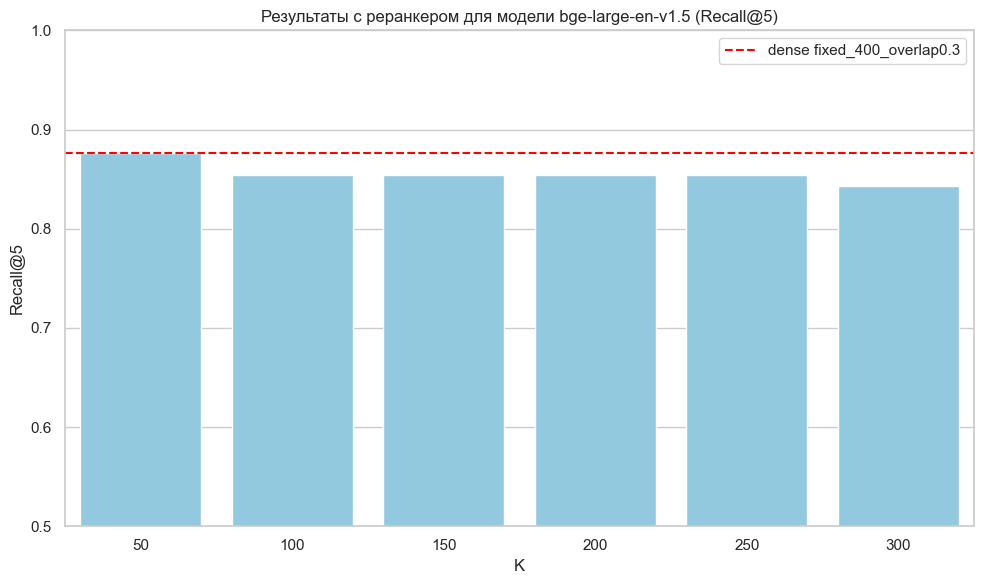

In [3]:
import json
import os
import re
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

folders = {
    "e5-large-v2": "metrics/metrics_dense_vs_cross_enc/metrics_cross_bge_reranker",
    "bge-large-en-v1.5": "metrics_bge_large_en_v_poltora/metrics_dense_vs_cross_enc/metrics_cross_bge_reranker"
}

sns.set(style="whitegrid")

for model, folder in folders.items():
    data = []
    dense_score = None

    for fname in os.listdir(folder):
        if fname.endswith(".json"):

            # извлекаем число K из имени файла
            match = re.search(r"_k(\d+)", fname)
            if match:
                k_val = int(match.group(1))
            else:
                k_val = 300  # если явно top300

            with open(os.path.join(folder, fname), "r") as f:
                metrics = json.load(f)

            # --- dense берём один раз ---
            if dense_score is None:
                d = metrics["dense"]
                dense_score = d["Recall@5"]

            # --- score реранкера ---
            r = metrics["reranker"]
            reranker_score = r["Recall@5"]

            data.append({"K": k_val, "Score": reranker_score})

    df = pd.DataFrame(data).sort_values("K")

    plt.figure(figsize=(10,6))
    sns.barplot(data=df, x="K", y="Score", color="skyblue")

    plt.title(f"Результаты с реранкером для модели {model} (Recall@5)")
    plt.ylabel("Recall@5")

    # 🔥 шкала Y начинается с 0.5
    plt.ylim(0.5, 1.0)

    # линия для базового dense
    if model == "e5-large-v2":
        plt.axhline(y=dense_score, color="red", linestyle="--",
                    label="dense fixed_250_overlap0.1")
    elif model == "bge-large-en-v1.5":
        plt.axhline(y=dense_score, color="red", linestyle="--",
                    label="dense fixed_400_overlap0.3")

    plt.legend()
    plt.tight_layout()
    plt.show()


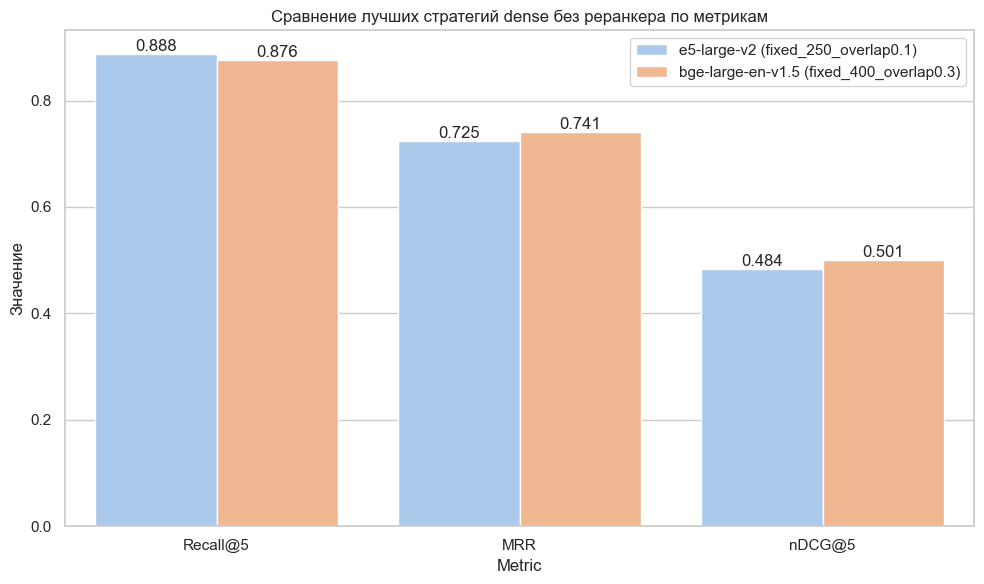

In [4]:
import json
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

files = {
    "e5-large-v2 (fixed_250_overlap0.1)": "metrics/metrics_dense_vs_cross_enc/metrics_cross_bge_reranker/metrics_results_dense_fixed_250_overlap0.1_top300__vs__results_reranker_bge_k50__k5.json",
    "bge-large-en-v1.5 (fixed_400_overlap0.3)": "metrics_bge_large_en_v_poltora/metrics_dense_vs_cross_enc/metrics_cross_bge_reranker/metrics_results_dense_fixed_400_overlap0.3_top300__vs__results_reranker_bge_k50__k5.json"
}

data = []
for label, path in files.items():
    with open(path, "r") as f:
        metrics = json.load(f)

    d = metrics["dense"]

    # 🔥 теперь добавляем только реальные метрики, без Score
    data.append({"Model": label, "Metric": "Recall@5", "Value": d["Recall@5"]})
    data.append({"Model": label, "Metric": "MRR", "Value": d["MRR"]})
    data.append({"Model": label, "Metric": "nDCG@5", "Value": d["nDCG@5"]})

df = pd.DataFrame(data)

sns.set(style="whitegrid")
plt.figure(figsize=(10,6))
ax = sns.barplot(data=df, x="Metric", y="Value", hue="Model", palette="pastel")

# подписи над столбцами
for p in ax.patches:
    val = p.get_height()
    if val > 0:
        ax.annotate(f"{val:.3f}",
                    (p.get_x() + p.get_width()/2., val),
                    ha="center", va="bottom")

plt.title("Сравнение лучших стратегий dense без реранкера по метрикам")
plt.ylabel("Значение")
plt.legend()
plt.tight_layout()
plt.show()


C:\Users\suslo\AppData\Local\Temp\ipykernel_21256\3253364038.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


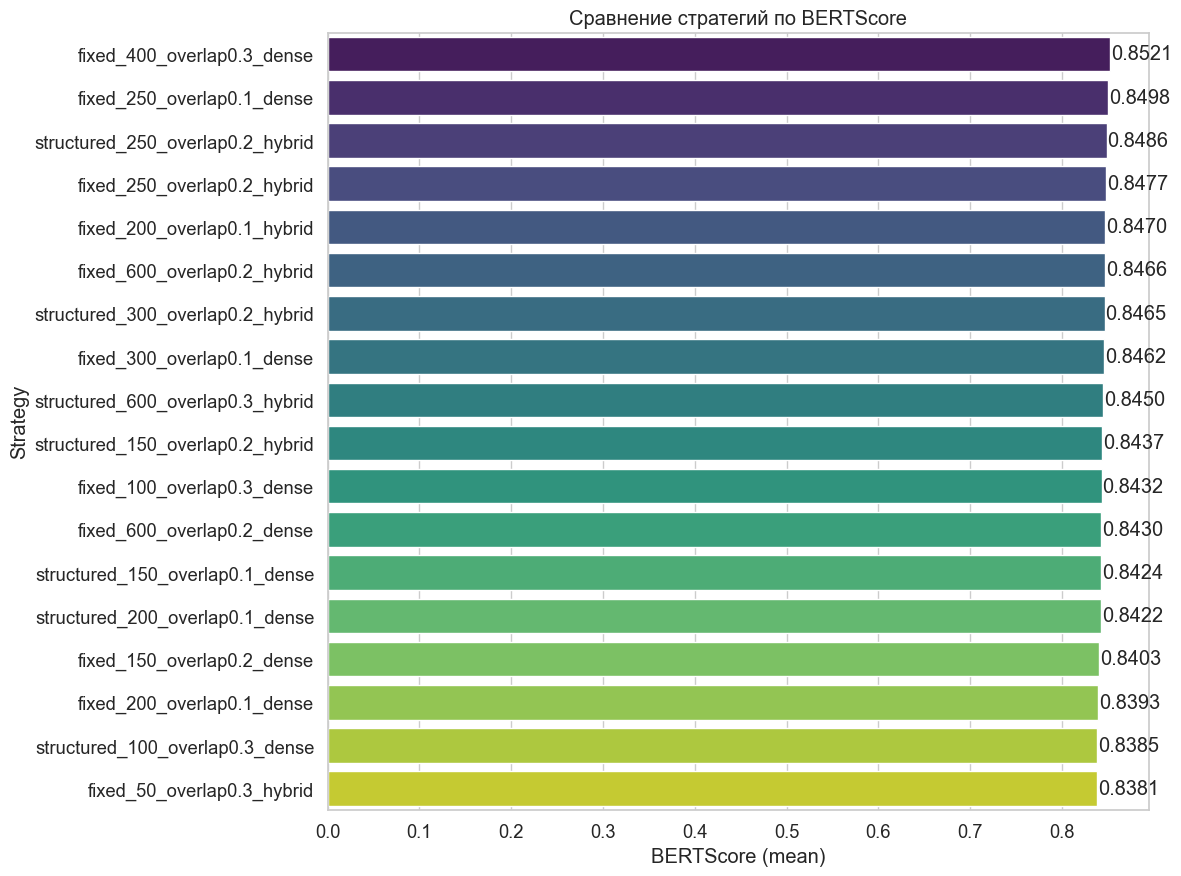

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

# Убираем слово "answers" из названий стратегий
summary_sorted["strategy_clean"] = summary_sorted["strategy"].str.replace("answers_", "", regex=False).str.strip()

# --- Настройки стиля ---
sns.set(style="whitegrid", font_scale=1.2)

plt.figure(figsize=(12, max(6, len(summary_sorted) * 0.5)))

# 🔥 Теперь строим график по BERTScore_mean
ax = sns.barplot(
    data=summary_sorted,
    x="BERTScore_mean",
    y="strategy_clean",
    palette="viridis"
)

# Подписи значений на барах
for i, v in enumerate(summary_sorted["BERTScore_mean"]):
    ax.text(
        v + 0.001,
        i,
        f"{v:.4f}",
        va="center"
    )

plt.title("Сравнение стратегий по BERTScore")
plt.xlabel("BERTScore (mean)")
plt.ylabel("Strategy")
plt.tight_layout()

plt.savefig(os.path.join(METRICS_DIR, "FINAL_BERTSCORE_RANKING_PLOT.png"), dpi=300)
plt.show()
